## I. Data Exploration

In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
import scipy.stats as stats

In [2]:
# Load the dataset
data_path = '/Users/silakeles/Desktop/MSCA691/diabetes_risk_dataset.csv'

df = pd.read_csv(data_path)

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")

Dataset loaded successfully!
Dataset shape: (6000, 19)


### Dataset Overview & Summary Statistics

In [3]:
print("=== DATASET OVERVIEW ===")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())

=== DATASET OVERVIEW ===
Shape: (6000, 19)

First 5 rows:
   Patient_ID  age  gender   bmi  blood_pressure  fasting_glucose_level  \
0           1   77  Female  33.8             154                     93   
1           2   54    Male  19.2             123                     94   
2           3   25    Male  33.7             141                    150   
3           4   23  Female  32.8             140                    145   
4           5   70    Male  33.7             165                     90   

   insulin_level  HbA1c_level  cholesterol_level  triglycerides_level  \
0           12.1          5.2                242                  194   
1            4.6          5.4                212                   76   
2           10.8          6.9                247                  221   
3           11.6          6.8                195                  193   
4           18.3          5.6                217                  170   

  physical_activity_level  daily_calorie_intake  sug

In [4]:
print("\nColumn names and data types:")
print(df.info())


Column names and data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Patient_ID                  6000 non-null   int64  
 1   age                         6000 non-null   int64  
 2   gender                      6000 non-null   object 
 3   bmi                         6000 non-null   float64
 4   blood_pressure              6000 non-null   int64  
 5   fasting_glucose_level       6000 non-null   int64  
 6   insulin_level               6000 non-null   float64
 7   HbA1c_level                 6000 non-null   float64
 8   cholesterol_level           6000 non-null   int64  
 9   triglycerides_level         6000 non-null   int64  
 10  physical_activity_level     6000 non-null   object 
 11  daily_calorie_intake        6000 non-null   int64  
 12  sugar_intake_grams_per_day  6000 non-null   float64
 13  sle

In [5]:
print("\n=== SUMMARY STATISTICS ===")
print(df.describe())


=== SUMMARY STATISTICS ===
        Patient_ID          age          bmi  blood_pressure  \
count  6000.000000  6000.000000  6000.000000     6000.000000   
mean   3000.500000    52.230667    32.939667      144.482500   
std    1732.195139    18.757508     7.510155       17.867248   
min       1.000000    20.000000    16.000000       91.000000   
25%    1500.750000    36.000000    26.900000      132.000000   
50%    3000.500000    53.000000    32.750000      144.000000   
75%    4500.250000    68.000000    38.500000      157.000000   
max    6000.000000    84.000000    50.000000      200.000000   

       fasting_glucose_level  insulin_level  HbA1c_level  cholesterol_level  \
count            6000.000000    6000.000000  6000.000000        6000.000000   
mean              106.105500      15.080333     5.784583         217.490667   
std                31.213994       9.245581     0.956614          24.888595   
min                60.000000       2.000000     4.100000         139.000000   


In [6]:
# Display categorical columns summary
categorical_cols = df.select_dtypes(include=['object']).columns
print(f"\nCategorical columns: {list(categorical_cols)}")


Categorical columns: ['gender', 'physical_activity_level', 'family_history_diabetes', 'diabetes_risk_category']


In [7]:
# Asses unique values for each non-numeric variable
for col in ["gender","physical_activity_level", "family_history_diabetes", "diabetes_risk_category"]:
    print(col)
    print(df[col].unique())
    print()

gender
['Female' 'Male']

physical_activity_level
['Low' 'High' 'Moderate']

family_history_diabetes
['No' 'Yes']

diabetes_risk_category
['Prediabetes' 'Low Risk' 'High Risk']



### Missing Values Analysis

In [8]:
# List number and percentage of missing values per variable
print("=== MISSING VALUES ANALYSIS ===")
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage': missing_percent
})
print(missing_info[missing_info['Missing Count'] > 0])

# Visualize missing values
plt.figure(figsize=(10, 8))
missing_plot_data = missing_info[missing_info['Missing Count'] > 0]
if not missing_plot_data.empty:
    plt.bar(missing_plot_data.index, missing_plot_data['Missing Percentage'])
    plt.title('Missing Values Percentage by Column', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45)
    plt.ylabel('Percentage Missing (%)')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

=== MISSING VALUES ANALYSIS ===
Empty DataFrame
Columns: [Missing Count, Missing Percentage]
Index: []


<Figure size 1000x800 with 0 Axes>

## II. Data Visualization

### Analysis of Numerical Variables

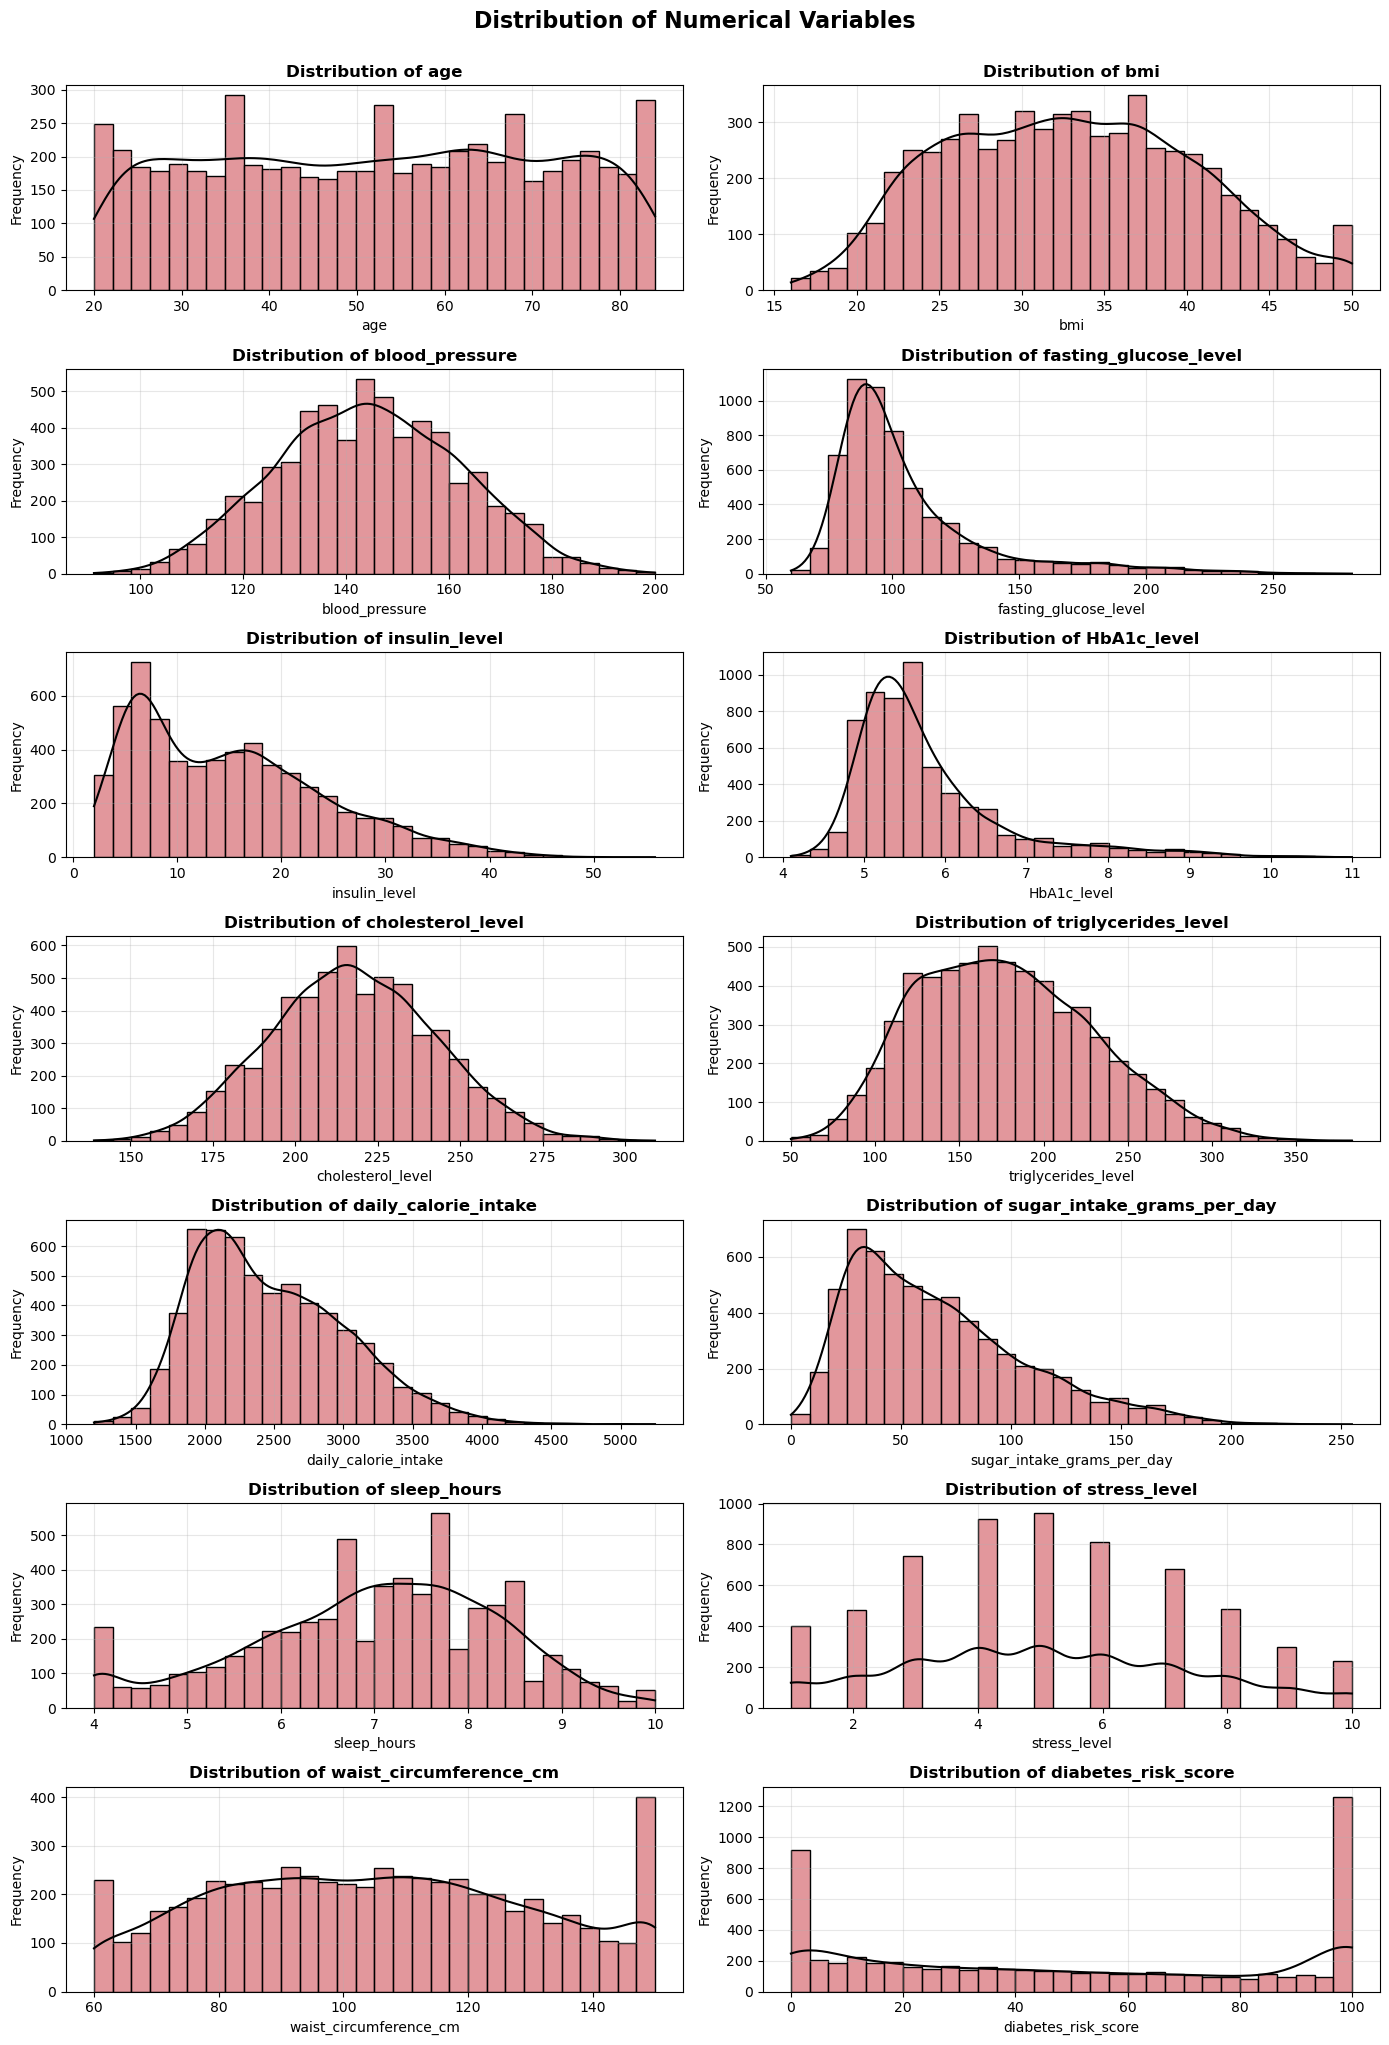

In [9]:
# Histograms for distribution of numerical variables

numerical_vars = ['age','bmi','blood_pressure','fasting_glucose_level','insulin_level',
                  'HbA1c_level','cholesterol_level','triglycerides_level',
                  'daily_calorie_intake','sugar_intake_grams_per_day',
                  'sleep_hours','stress_level','waist_circumference_cm',
                  'diabetes_risk_score']

fig, axes = plt.subplots(7, 2, figsize=(14, 20))
axes = axes.ravel()

for i, col in enumerate(numerical_vars):
    ax = axes[i]
    sns.histplot(df[col],
                 bins=30,
                 kde=True,
                 ax=ax,
                 color='#D76B73',
                 edgecolor='black',
                 alpha=0.7)
    if ax.lines:
        ax.lines[-1].set_color('black')
        ax.lines[-1].set_linewidth(1.5)

    ax.set_title(f'Distribution of {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('Distribution of Numerical Variables', fontsize=16, fontweight='bold', y=1.02)
plt.show()

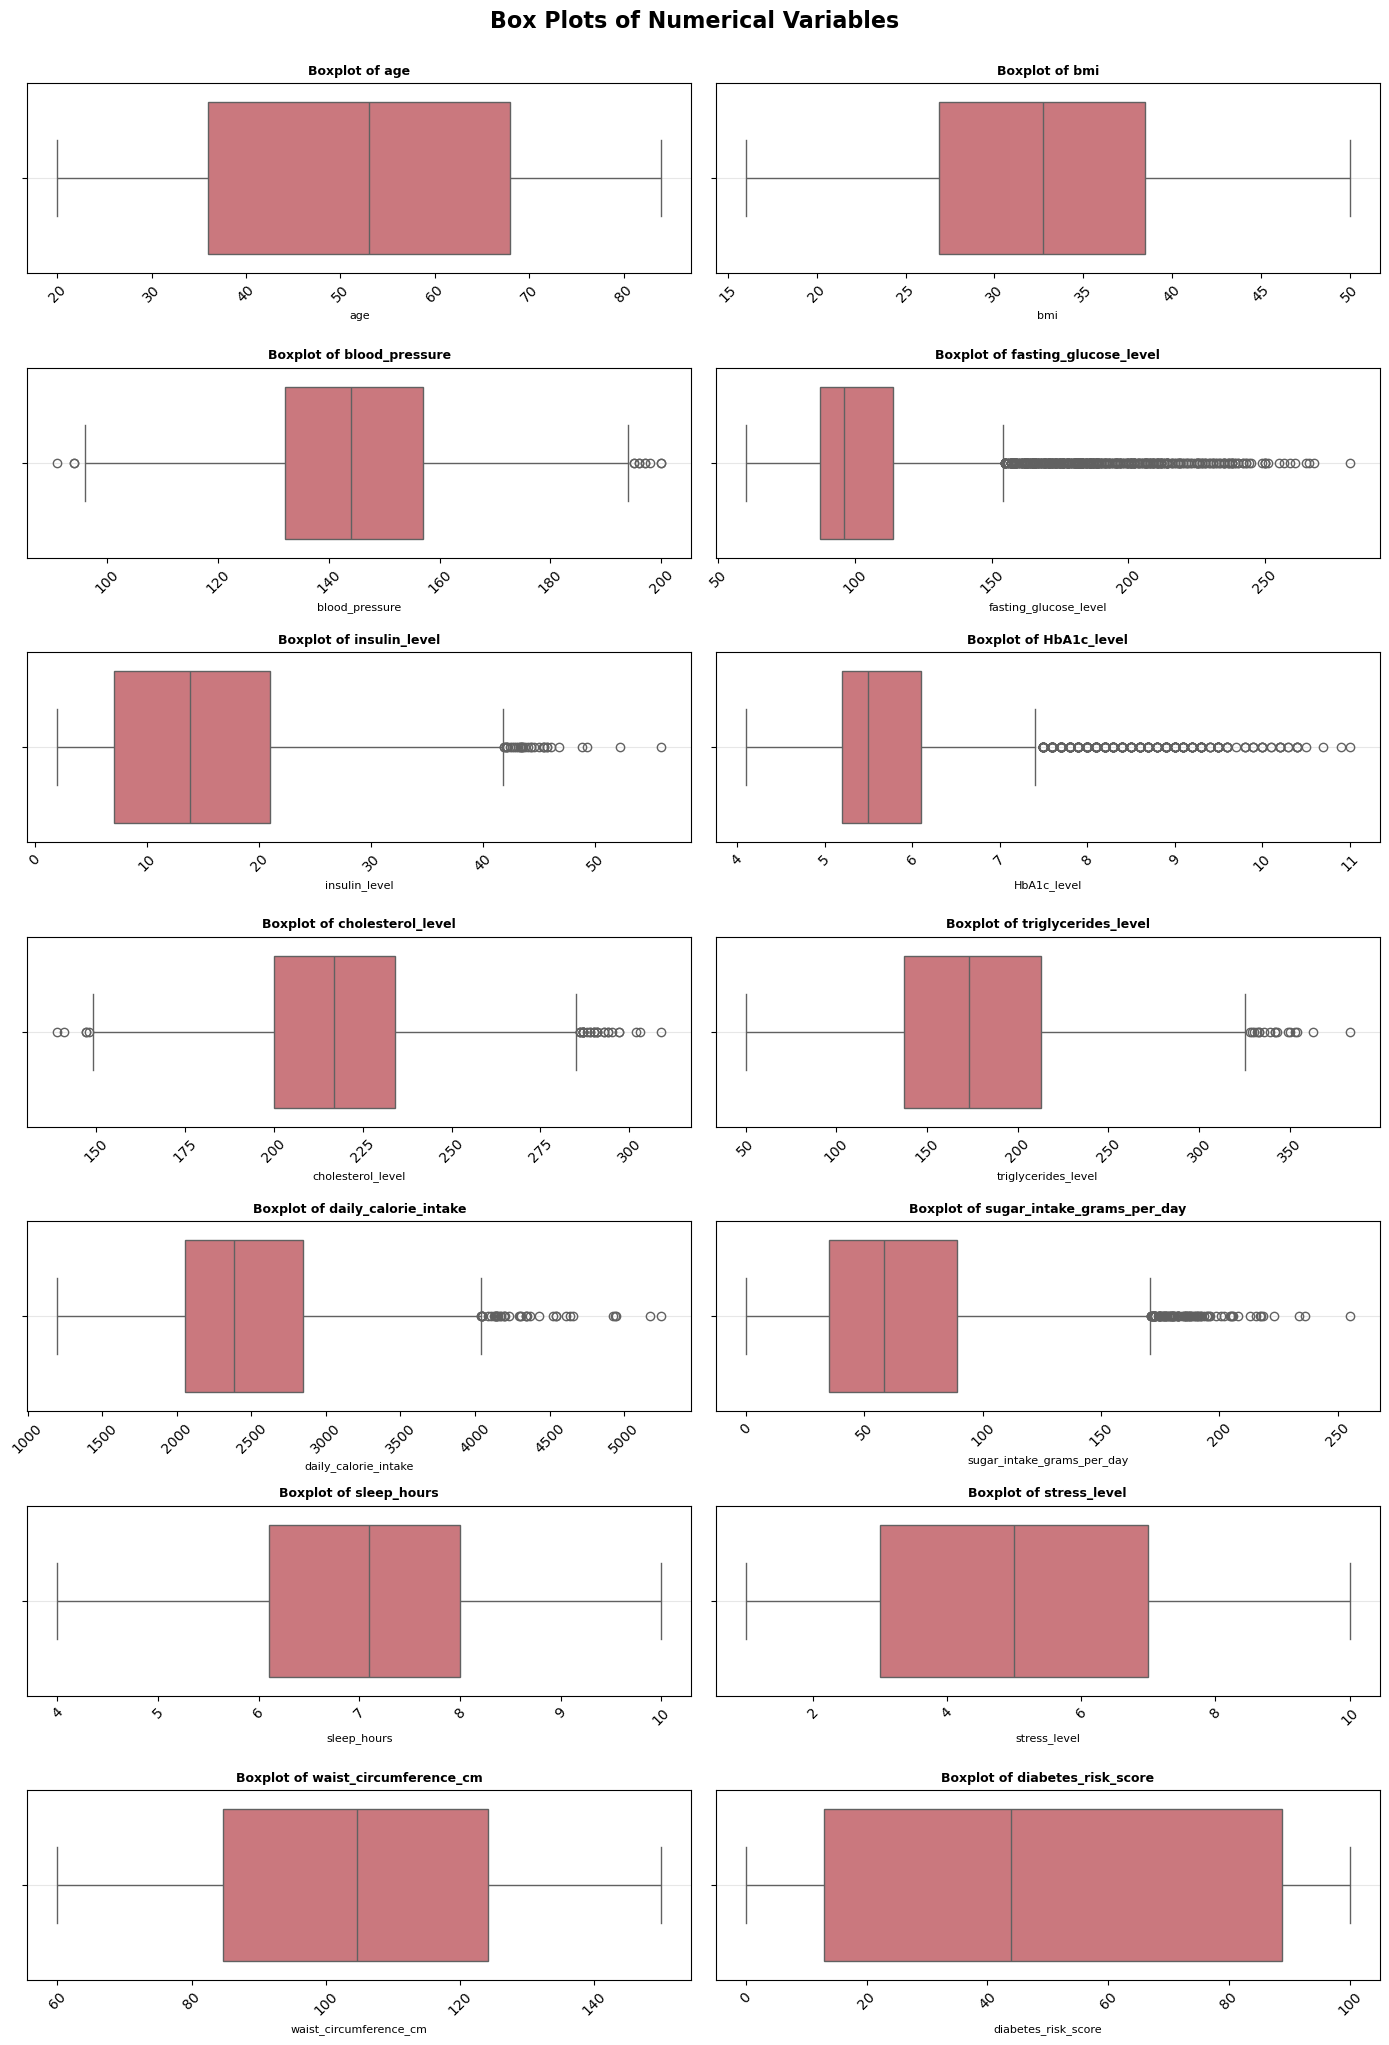

In [10]:
# Boxplot for distribution of numerical variables

fig, axes = plt.subplots(7, 2, figsize=(14, 20))  
axes = axes.ravel()

for i, col in enumerate(numerical_vars):
    sns.boxplot(
        data=df,
        x=col,
        color='#D76B73',
        ax=axes[i]
    )

    axes[i].set_title(f'Boxplot of {col}', fontweight='bold', fontsize=9)  
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.suptitle('Box Plots of Numerical Variables', fontsize=16, fontweight='bold', y=1.02)
plt.show()

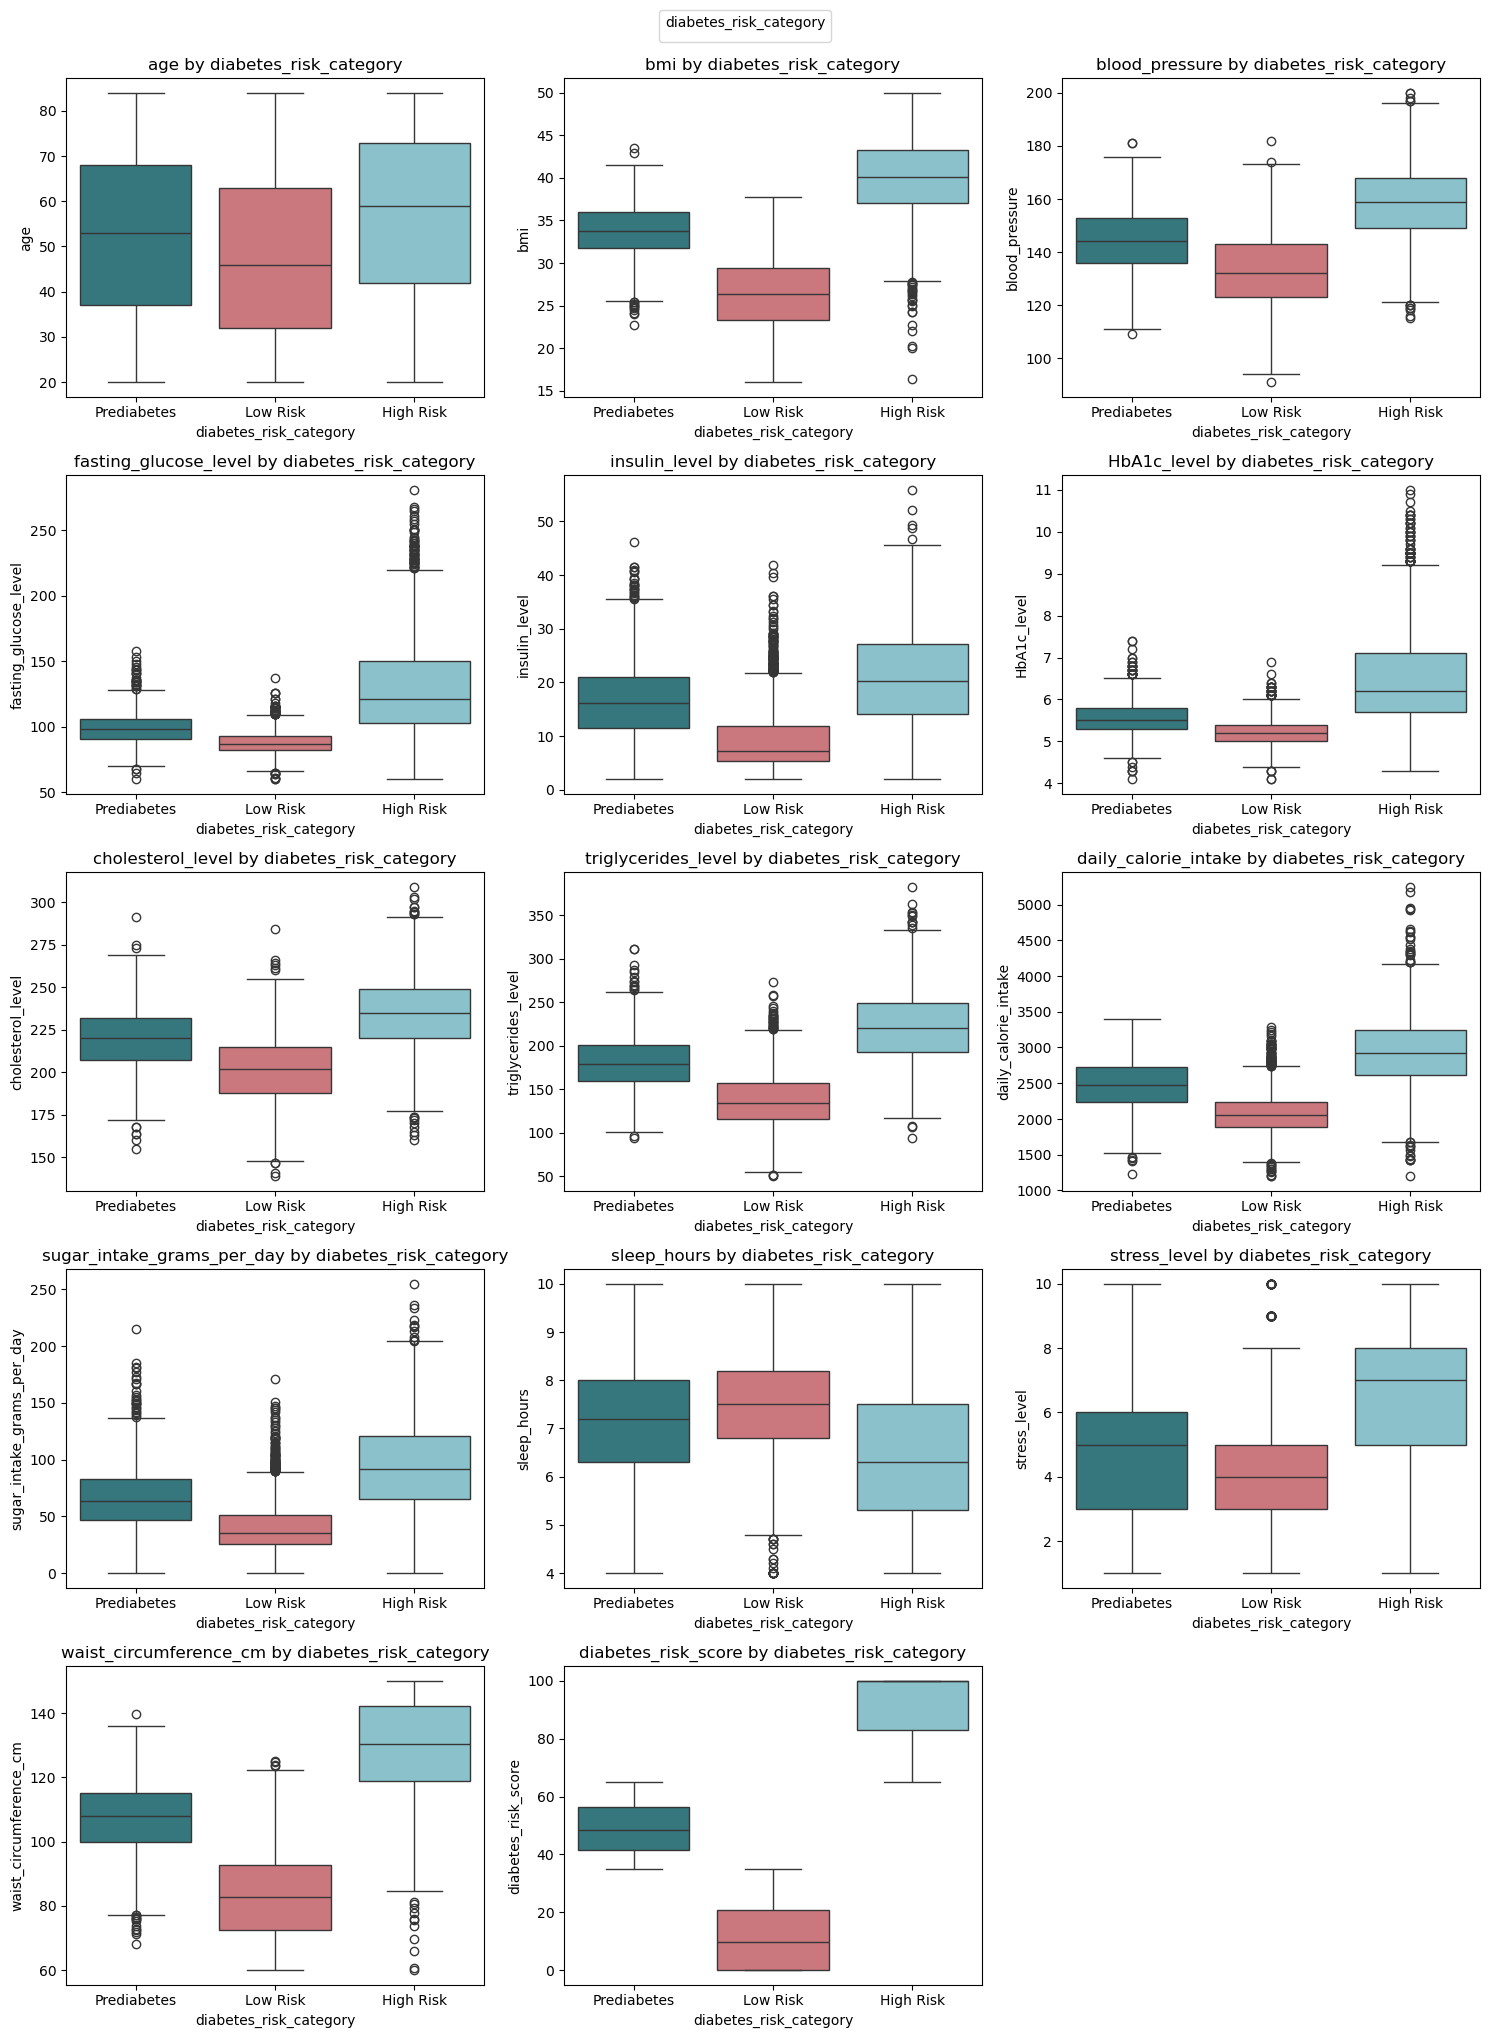

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

target = "diabetes_risk_category"

numeric_columns = df.select_dtypes(include=["float64", "int64"]).columns
numeric_columns = [col for col in numeric_columns if col not in [target, "Patient_ID"]]

n_cols = 3
n_rows = (len(numeric_columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

palette = ["#2A7F89", "#D76B73", "#7FC8D6"]

for i, column in enumerate(numeric_columns):
    sns.boxplot(
        ax=axes[i],
        x=target,
        y=column,
        data=df,
        hue=target,
        dodge=False,
        palette=palette
    )
    axes[i].set_title(f"{column} by {target}")
    axes[i].set_xlabel(target)
    axes[i].set_ylabel(column)

    if axes[i].legend_ is not None:
        axes[i].legend_.remove()

for i in range(len(numeric_columns), len(axes)):
    fig.delaxes(axes[i])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title=target, loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=3)

plt.tight_layout()
plt.show()

### Analysis of Categorical Variables

DISTRIBUTION OF CATEGORICAL VARIABLES (COUNT)

Unique category counts per variable:
gender                     2
physical_activity_level    3
family_history_diabetes    2
diabetes_risk_category     3
dtype: int64


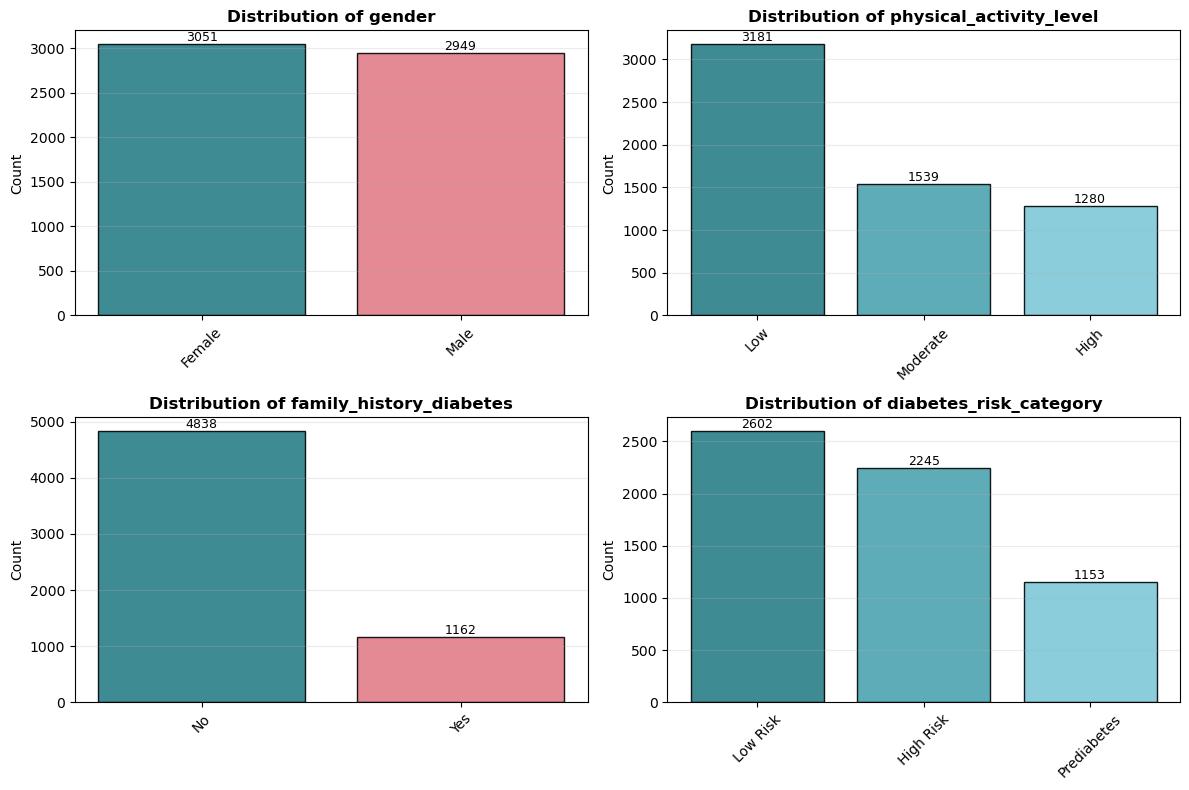

In [12]:
import matplotlib.pyplot as plt

print("DISTRIBUTION OF CATEGORICAL VARIABLES (COUNT)")

categorical_vars = [
    "gender",
    "physical_activity_level",
    "family_history_diabetes",
    "diabetes_risk_category"
]

# check unique categories for each variable
print("\nUnique category counts per variable:")
print(df[categorical_vars].nunique())

for i in range(0, len(categorical_vars), 4):
    subset = categorical_vars[i:i+4]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    for j, col in enumerate(subset):
        if col in df.columns:

            value_counts = df[col].astype(str).value_counts(dropna=False)

            if len(value_counts) == 2:
                colors = ['#2A7F89', '#E27D8A']  
            else:
                multi_palette = ['#2A7F89', '#4CA3AF', '#7FC8D6',
                                 '#A8DDE6', '#CFEFF5']
                colors = multi_palette[:len(value_counts)]

            bars = axes[j].bar(
                value_counts.index,
                value_counts.values,
                color=colors,
                edgecolor='black',
                alpha=0.9
            )

            axes[j].set_title(f'Distribution of {col}',
                              fontweight='bold',
                              fontsize=12)

            axes[j].set_ylabel('Count')
            axes[j].tick_params(axis='x', rotation=45)
            axes[j].grid(axis='y', alpha=0.25)

            for bar in bars:
                h = bar.get_height()
                axes[j].text(
                    bar.get_x() + bar.get_width()/2,
                    h,
                    f'{int(h)}',
                    ha='center',
                    va='bottom',
                    fontsize=9
                )

    for k in range(len(subset), 4):
        fig.delaxes(axes[k])

    plt.tight_layout()
    plt.show()

CATEGORICAL VARIABLES vs DIABETES_RISK_SCORE (AVG)


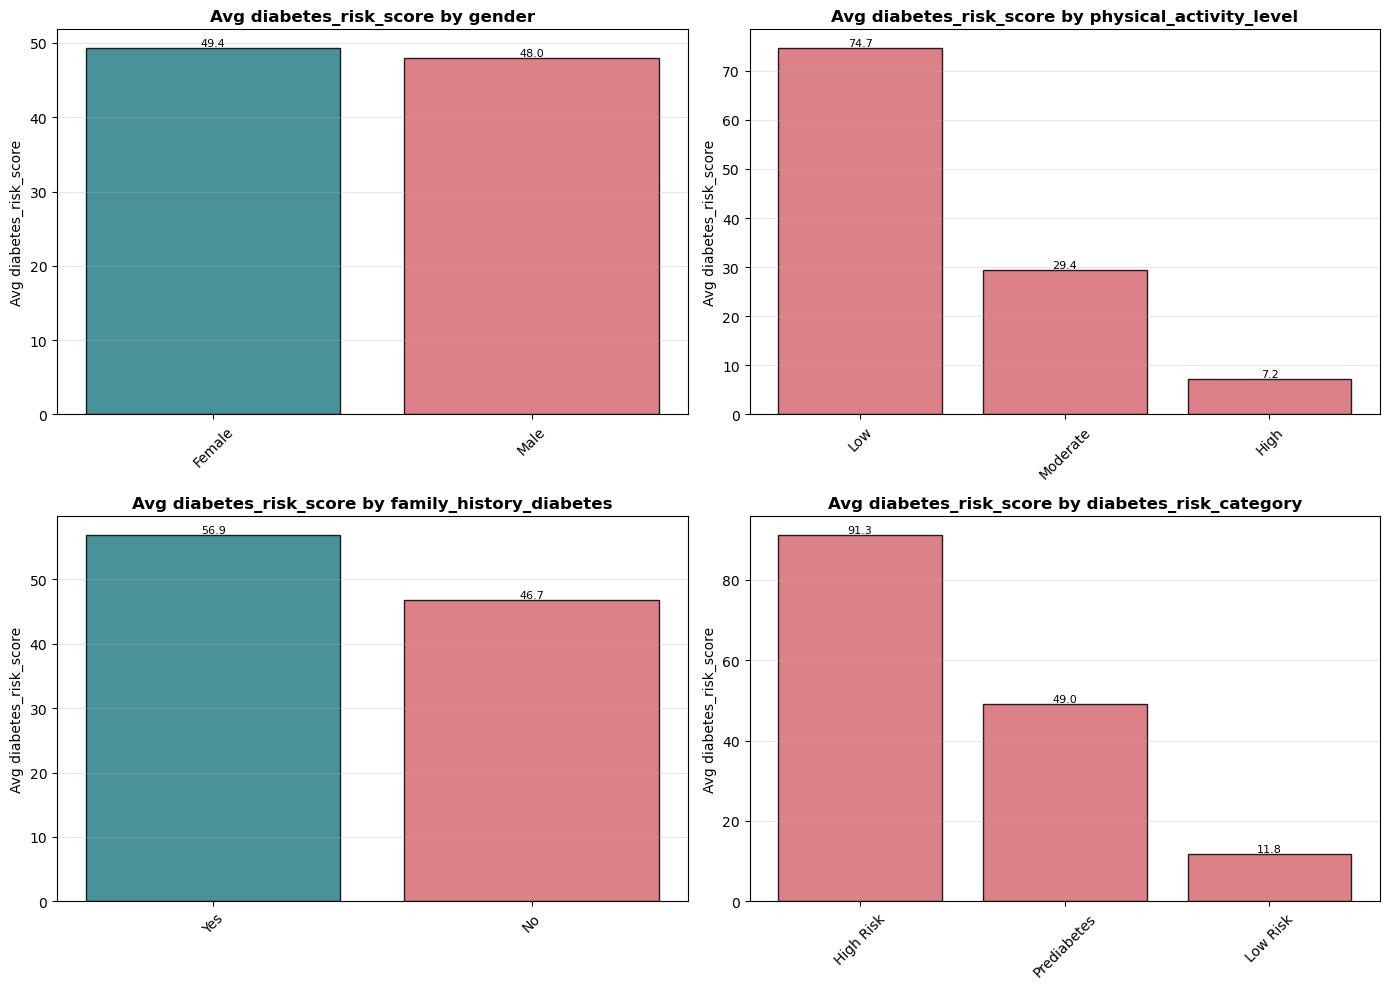

In [13]:
import matplotlib.pyplot as plt

print("CATEGORICAL VARIABLES vs DIABETES_RISK_SCORE (AVG)")

categorical_vars = [
    "gender",
    "physical_activity_level",
    "family_history_diabetes",
    "diabetes_risk_category"   
]

y_var = "diabetes_risk_score"

for i in range(0, len(categorical_vars), 4):
    subset = categorical_vars[i:i+4]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for j, col in enumerate(subset):
        if col in df.columns and y_var in df.columns:

            grouped = (
                df.groupby(col)[y_var]
                  .mean()
                  .sort_values(ascending=False)
            )

            if len(grouped) > 10:
                grouped = grouped.head(10)

            # binary 
            if len(grouped) == 2:
                colors = ['#2A7F89', '#D76B73']
            else:
                colors = ['#D76B73'] * len(grouped)

            bars = axes[j].bar(
                grouped.index.astype(str),
                grouped.values,
                color=colors,
                edgecolor='black',
                alpha=0.85
            )

            axes[j].set_title(f'Avg {y_var} by {col}', fontweight='bold')
            axes[j].set_ylabel(f'Avg {y_var}')
            axes[j].tick_params(axis='x', rotation=45)
            axes[j].grid(axis='y', alpha=0.3)

            for bar in bars:
                h = bar.get_height()
                axes[j].text(bar.get_x() + bar.get_width()/2,
                             h,
                             f'{h:.1f}',
                             ha='center',
                             va='bottom',
                             fontsize=8)

    for k in range(len(subset), 4):
        fig.delaxes(axes[k])

    plt.tight_layout()
    plt.show()

CATEGORICAL VARIABLES vs DIABETES_RISK_CATEGORY (COUNT SPLIT)


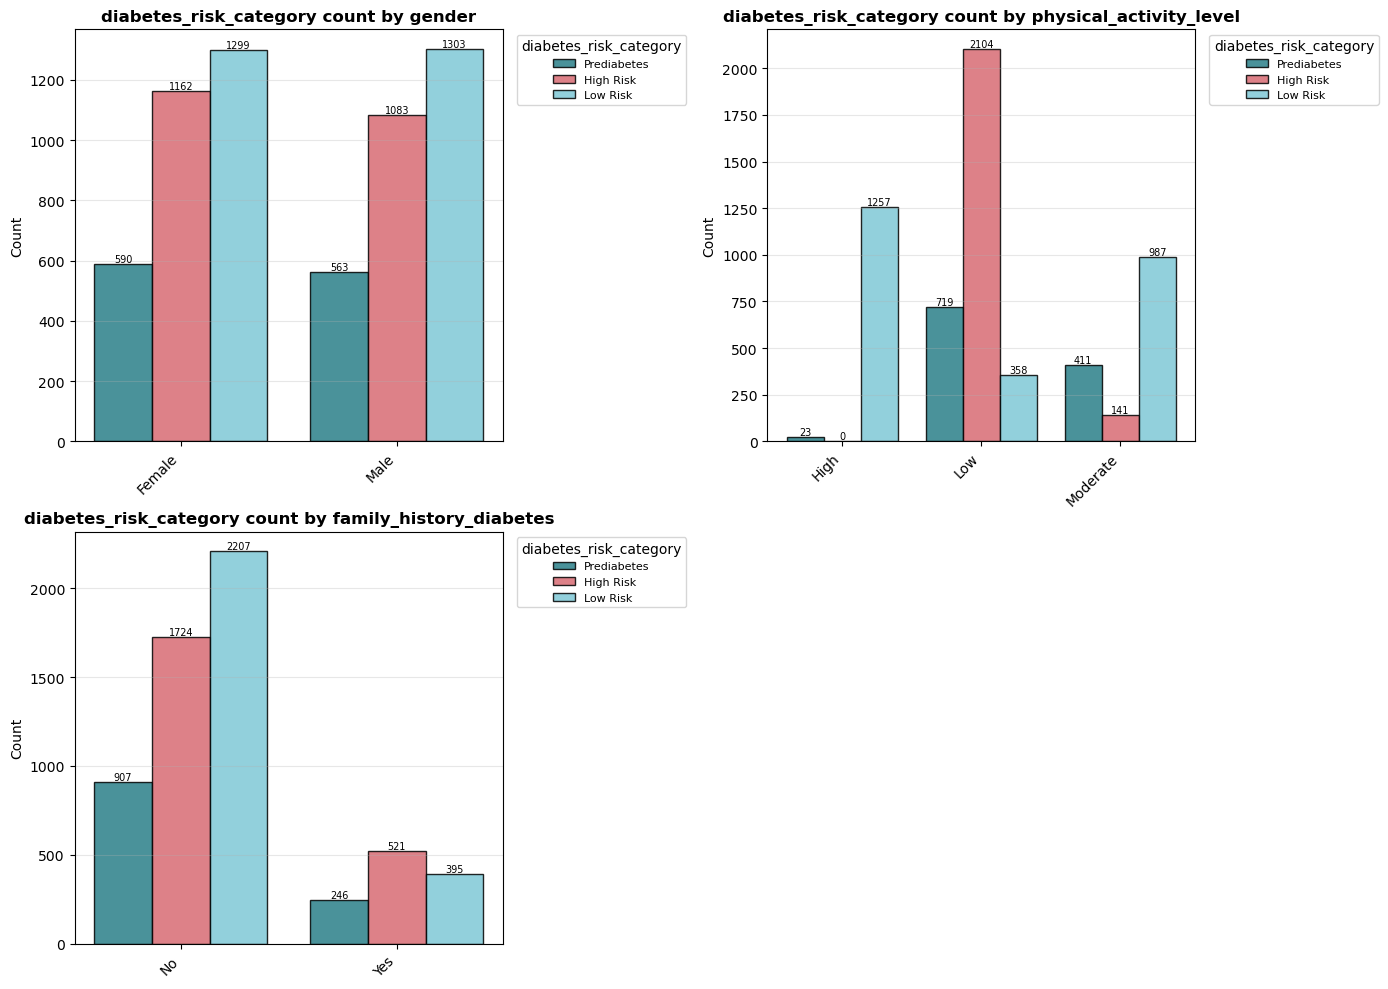

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("CATEGORICAL VARIABLES vs DIABETES_RISK_CATEGORY (COUNT SPLIT)")

categorical_vars = [
    "gender",
    "physical_activity_level",
    "family_history_diabetes"
]

outcome_cat = "diabetes_risk_category"

desired_classes = ["Low", "Prediabetes", "High"]

for i in range(0, len(categorical_vars), 4):
    subset = categorical_vars[i:i+4]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for j, col in enumerate(subset):
        if col in df.columns and outcome_cat in df.columns:

            ct = pd.crosstab(df[col].astype(str), df[outcome_cat].astype(str))

            class_order = [c for c in desired_classes if c in ct.columns]
            extras = [c for c in ct.columns if c not in class_order]
            class_order = class_order + extras
            ct = ct[class_order]

            if len(ct) > 10:
                ct = ct.loc[ct.sum(axis=1).sort_values(ascending=False).head(10).index]

            x = np.arange(len(ct.index))
            n_classes = len(ct.columns)
            width = 0.8 / n_classes

            palette = ['#2A7F89', '#D76B73', '#7FC8D6', '#A8DDE6', '#CFEFF5']
            colors = palette[:n_classes]

            for idx, cls in enumerate(ct.columns):
                bars = axes[j].bar(
                    x + (idx - (n_classes - 1)/2) * width,
                    ct[cls].values,
                    width=width,
                    label=cls,
                    color=colors[idx],
                    edgecolor='black',
                    alpha=0.85
                )

                for bar in bars:
                    h = bar.get_height()
                    axes[j].text(bar.get_x() + bar.get_width()/2,
                                 h,
                                 f'{int(h)}',
                                 ha='center',
                                 va='bottom',
                                 fontsize=7)

            axes[j].set_title(f'{outcome_cat} count by {col}', fontweight='bold')
            axes[j].set_ylabel('Count')
            axes[j].set_xticks(x)
            axes[j].set_xticklabels(ct.index.astype(str), rotation=45, ha='right')
            axes[j].grid(axis='y', alpha=0.3)
            axes[j].legend(title=outcome_cat,
               fontsize=8,
               loc='upper left',
               bbox_to_anchor=(1.02, 1))

    for k in range(len(subset), 4):
        fig.delaxes(axes[k])

    plt.tight_layout()
    plt.show()

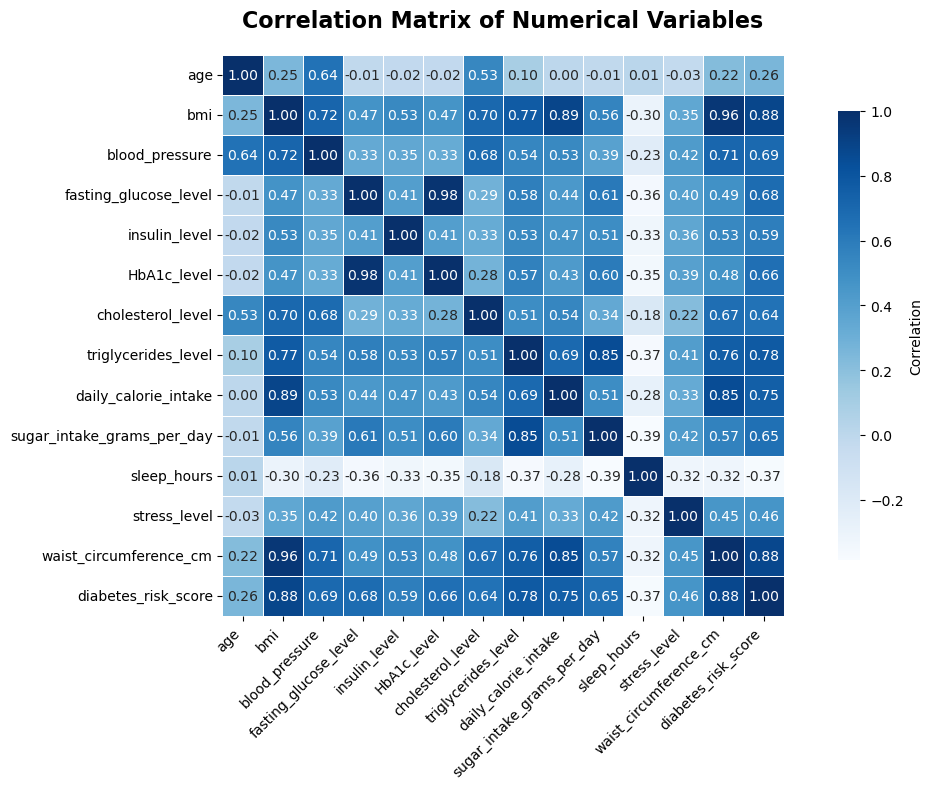


HIGH CORRELATION PAIRS (|corr| > 0.60):
HbA1c_level  ↔  fasting_glucose_level  :  0.977
waist_circumference_cm  ↔  bmi  :  0.960
daily_calorie_intake  ↔  bmi  :  0.891
diabetes_risk_score  ↔  bmi  :  0.883
diabetes_risk_score  ↔  waist_circumference_cm  :  0.881
waist_circumference_cm  ↔  daily_calorie_intake  :  0.854
sugar_intake_grams_per_day  ↔  triglycerides_level  :  0.851
diabetes_risk_score  ↔  triglycerides_level  :  0.777
triglycerides_level  ↔  bmi  :  0.768
waist_circumference_cm  ↔  triglycerides_level  :  0.756
diabetes_risk_score  ↔  daily_calorie_intake  :  0.749
blood_pressure  ↔  bmi  :  0.717
waist_circumference_cm  ↔  blood_pressure  :  0.710
cholesterol_level  ↔  bmi  :  0.702
diabetes_risk_score  ↔  blood_pressure  :  0.694
daily_calorie_intake  ↔  triglycerides_level  :  0.694
cholesterol_level  ↔  blood_pressure  :  0.683
diabetes_risk_score  ↔  fasting_glucose_level  :  0.677
waist_circumference_cm  ↔  cholesterol_level  :  0.669
diabetes_risk_score  ↔  HbA1c_

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_vars = df.select_dtypes(include=["float64", "int64"]).columns
numerical_vars = [col for col in numerical_vars if col != "Patient_ID"]

correlation_data = df[numerical_vars].corr()

plt.figure(figsize=(12, 8))

ax = sns.heatmap(
    correlation_data,
    annot=True,
    cmap="Blues",
    square=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"shrink": 0.8, "label": "Correlation"}
)

ax.set_title(
    "Correlation Matrix of Numerical Variables",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

# List highly correlated variable pairs
threshold = 0.60
print("\nHIGH CORRELATION PAIRS (|corr| > 0.60):")

high_corr_pairs = []

corr_matrix = correlation_data.abs()

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        corr_value = correlation_data.iloc[i, j]
        if abs(corr_value) > threshold:
            var1 = corr_matrix.columns[i]
            var2 = corr_matrix.columns[j]
            high_corr_pairs.append((var1, var2, corr_value))

if high_corr_pairs:
    for var1, var2, corr_value in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"{var1}  ↔  {var2}  :  {corr_value:.3f}")
else:
    print("No variable pairs exceed the threshold.")

## III. Data Preprocessing

### Dummy Encoding

In [16]:
import pandas as pd

categorical_to_encode = [
    'gender',
    'physical_activity_level',
    'family_history_diabetes'
]

df_encoded = df.copy()

for col in categorical_to_encode:
    if col in df_encoded.columns:
        dummies = pd.get_dummies(df_encoded[col], prefix=col, drop_first=True)
        df_encoded = pd.concat([df_encoded, dummies], axis=1)
        df_encoded.drop(col, axis=1, inplace=True)

print("Dummy encoding completed.")
print("Current shape:", df_encoded.shape)

Dummy encoding completed.
Current shape: (6000, 20)


### Variable Selection

In [17]:
# Convert categorical variables to numerical using dummy variables

features_to_drop = [
    'Patient_ID',
    'diabetes_risk_score',       
    'HbA1c_level',                
    'waist_circumference_cm'      
]

X = df_encoded.drop(features_to_drop + ['diabetes_risk_category'], axis=1, errors='ignore')
y = df_encoded['diabetes_risk_category']

print(f"Final feature set shape: {X.shape}")
print(f"Target variable shape: {y.shape}")

Final feature set shape: (6000, 15)
Target variable shape: (6000,)


### Data Partitioning

In [18]:
# Split data set into 80% training and 20% test set

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Number of features: {X_train.shape[1]}")

Training set: 4800 samples
Test set: 1200 samples
Number of features: 15


### Data Standardization

In [19]:
# Standardize the sets
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train)

train_X_std = pd.DataFrame(
    scaler.transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

test_X_std = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

## IV. Model Selection

## Logistic Regression

#### Method 1: Without Hyperparameter Tuning

Accuracy: 0.9375
Area Under ROC curve (AUC): 0.990742326604344

Confusion Matrix:
 [[451   0  18]
 [  0 483  23]
 [ 18  16 191]]


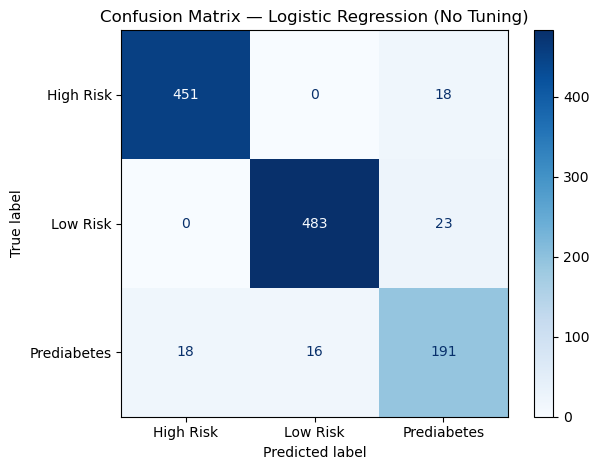

Train AUC: 0.9925  |  Test AUC: 0.9907
Train Accuracy: 0.946
Test Accuracy:  0.938


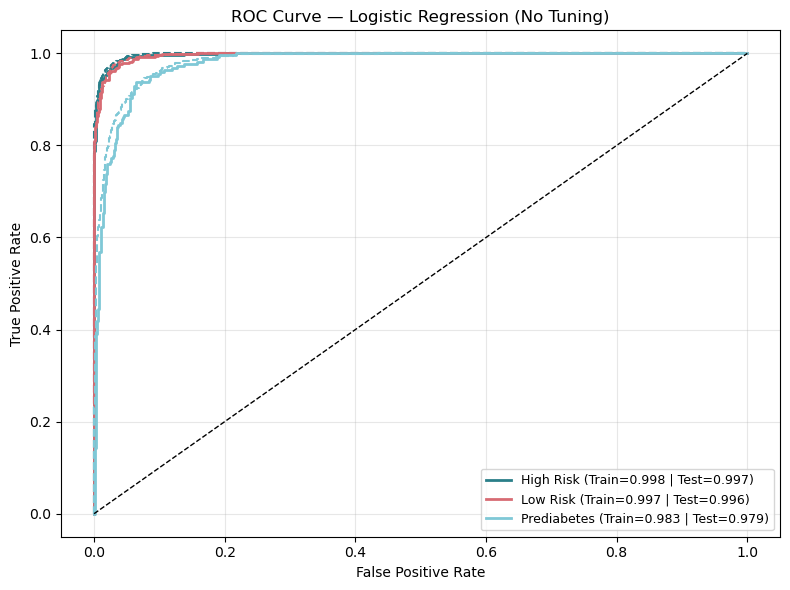

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# full metrics report (train + test) 
def classification_evaluation(model, X_train, y_train, X_test, y_test, threshold=0.5):
    train_proba  = model.predict_proba(X_train)
    test_proba   = model.predict_proba(X_test)
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)
    print(f"Training ROC AUC score (OvR, macro): {roc_auc_score(y_train, train_proba, multi_class='ovr', average='macro')}")
    print(f"Testing ROC AUC score (OvR, macro): {roc_auc_score(y_test, test_proba, multi_class='ovr', average='macro')}")
    print(f"Train Accuracy: {accuracy_score(y_train, y_pred_train):.3f}")
    print(f"Test Accuracy:  {accuracy_score(y_test,  y_pred_test):.3f}")
    print(f"Train Precision (macro): {precision_score(y_train, y_pred_train, average='macro', zero_division=0):.3f}")
    print(f"Test Precision (macro):  {precision_score(y_test,  y_pred_test,  average='macro', zero_division=0):.3f}")
    print(f"Train Recall (macro): {recall_score(y_train, y_pred_train, average='macro', zero_division=0):.3f}")
    print(f"Test Recall (macro):  {recall_score(y_test,  y_pred_test,  average='macro', zero_division=0):.3f}")
    print(f"Train F1 Score (macro): {f1_score(y_train, y_pred_train, average='macro', zero_division=0):.3f}")
    print(f"Test F1 Score (macro):  {f1_score(y_test,  y_pred_test,  average='macro', zero_division=0):.3f}")
    print("\nConfusion Matrix (Test):\n", confusion_matrix(y_test, y_pred_test))
    print("\nClassification Report (Test):\n", classification_report(y_test, y_pred_test))

#  ROC curve — train (dashed) + test (solid) per class)
def multiclass_roc_curve(model, X_train, y_train, X_test, y_test, model_name=''):
    classes     = model.classes_
    train_proba = model.predict_proba(X_train)
    test_proba  = model.predict_proba(X_test)
    y_train_bin = label_binarize(y_train, classes=classes)
    y_test_bin  = label_binarize(y_test,  classes=classes)

    train_auc = roc_auc_score(y_train, train_proba, multi_class='ovr', average='macro')
    test_auc  = roc_auc_score(y_test,  test_proba,  multi_class='ovr', average='macro')
    print(f"Train AUC: {train_auc:.4f}  |  Test AUC: {test_auc:.4f}")
    print(f"Train Accuracy: {accuracy_score(y_train, model.predict(X_train)):.3f}")
    print(f"Test Accuracy:  {accuracy_score(y_test,  model.predict(X_test)):.3f}")

    colors = ['#2A7F89', '#D76B73', '#7FC8D6']
    plt.figure(figsize=(8, 6))
    for i, (cls, color) in enumerate(zip(classes, colors)):
        fpr_tr, tpr_tr, _ = roc_curve(y_train_bin[:, i], train_proba[:, i])
        fpr_te, tpr_te, _ = roc_curve(y_test_bin[:, i],  test_proba[:, i])
        auc_tr = roc_auc_score(y_train_bin[:, i], train_proba[:, i])
        auc_te = roc_auc_score(y_test_bin[:, i],  test_proba[:, i])
        plt.plot(fpr_tr, tpr_tr, color=color, linestyle='--', linewidth=1.5)
        plt.plot(fpr_te, tpr_te, color=color, linestyle='-',  linewidth=2,
                 label=f"{cls} (Train={auc_tr:.3f} | Test={auc_te:.3f})")
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {model_name}")
    plt.legend(loc='lower right', fontsize=9)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


#  Method 1: Logistic Regression — no tuning 
logistic_reg = LogisticRegression(max_iter=1000)
logistic_reg.fit(train_X_std, y_train)

y_pred        = logistic_reg.predict(test_X_std)
probabilities = logistic_reg.predict_proba(test_X_std)

acc = metrics.accuracy_score(y_test, y_pred)
auc = metrics.roc_auc_score(y_test, probabilities, multi_class='ovr', average='macro')
print(f"Accuracy: {acc}")
print(f"Area Under ROC curve (AUC): {auc}")
print("\nConfusion Matrix:\n", metrics.confusion_matrix(y_test, y_pred))

metrics.ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=logistic_reg.classes_,
    cmap='Blues'
)
plt.title("Confusion Matrix — Logistic Regression (No Tuning)")
plt.tight_layout()
plt.show()

multiclass_roc_curve(logistic_reg, train_X_std, y_train, test_X_std, y_test, model_name="Logistic Regression (No Tuning)")


#### Method 2: With Hyperparameter Tuning

In [21]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Validation split from training set
X_train_val, X_valid, y_train_val, y_valid = train_test_split(
    train_X_std, y_train, test_size=0.2, random_state=0, stratify=y_train
)

# Step 1 — Define C search space (logspace -2 to 2, 10 values)
c_set = np.logspace(-2, 2, 10)

# Step 2 — Train on train_val, score on valid for each C
Valid_Acc_list = []
for c in c_set:
    LR = LogisticRegression(C=c, max_iter=2000, random_state=0)
    LR.fit(X_train_val, y_train_val)
    Valid_Acc_list.append(LR.score(X_valid, y_valid))

# Step 3 — Pick best C
best_param     = c_set[np.argmax(Valid_Acc_list)]
best_valid_acc = max(Valid_Acc_list)
print(f"Best C: {round(best_param, 5)}   Validation Accuracy: {round(best_valid_acc, 5)}")


Best C: 12.9155   Validation Accuracy: 0.93958


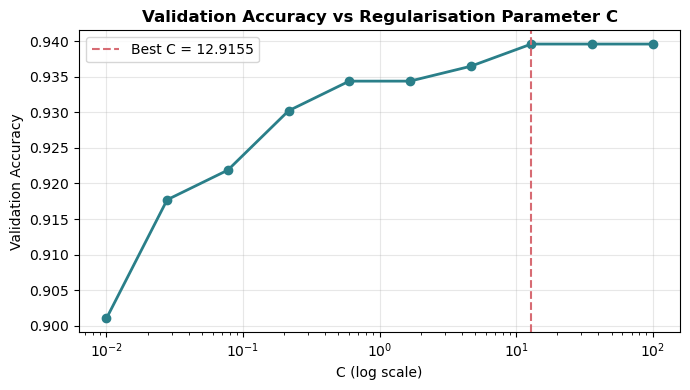

In [22]:
# Plot Validation Accuracy vs C
plt.figure(figsize=(7, 4))
plt.semilogx(c_set, Valid_Acc_list, marker='o', color='#2A7F89', linewidth=2)
plt.axvline(best_param, color='#D76B73', linestyle='--',
            label=f'Best C = {round(float(best_param), 4)}')
plt.title("Validation Accuracy vs Regularisation Parameter C", fontweight='bold')
plt.xlabel("C (log scale)")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

# Retrain with best C on full training set
LR = LogisticRegression(C=best_param, max_iter=2000, random_state=0)
LR.fit(train_X_std, y_train)

y_pred_LR  = LR.predict(test_X_std)
y_proba_LR = LR.predict_proba(test_X_std)

accuracy_LR = LR.score(test_X_std, y_test)
test_auc    = roc_auc_score(y_test, y_proba_LR, multi_class='ovr', average='macro')

print(f"Test Accuracy: {round(float(accuracy_LR), 5)}")
print(f"Test AUC (OvR macro): {round(float(test_auc), 5)}")
print(confusion_matrix(y_test, y_pred_LR))
print(classification_report(y_test, y_pred_LR))


Test Accuracy: 0.93667
Test AUC (OvR macro): 0.9909
[[450   0  19]
 [  0 482  24]
 [ 17  16 192]]
              precision    recall  f1-score   support

   High Risk       0.96      0.96      0.96       469
    Low Risk       0.97      0.95      0.96       506
 Prediabetes       0.82      0.85      0.83       225

    accuracy                           0.94      1200
   macro avg       0.92      0.92      0.92      1200
weighted avg       0.94      0.94      0.94      1200



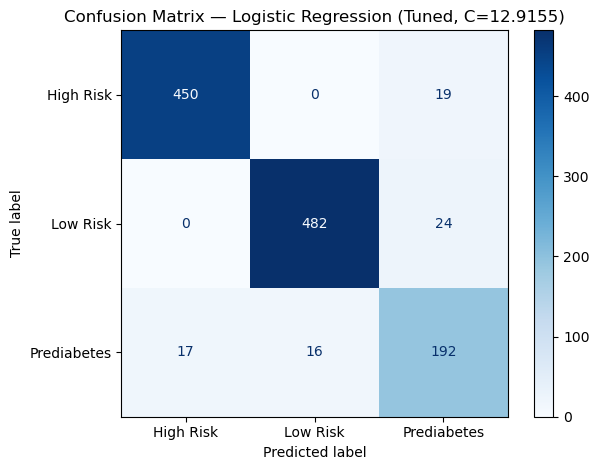

Train AUC: 0.9928  |  Test AUC: 0.9909
Train Accuracy: 0.947
Test Accuracy:  0.937


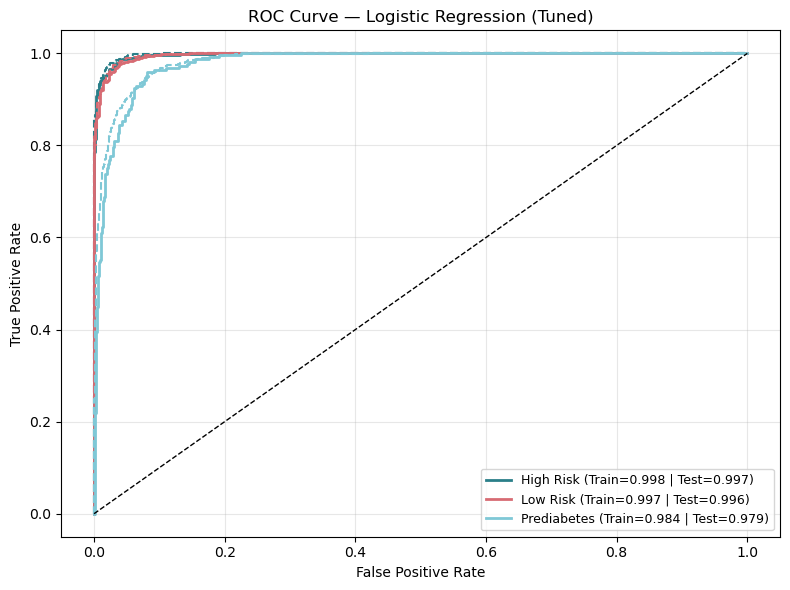

In [24]:
# Confusion Matrix
metrics.ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_LR,
    display_labels=LR.classes_,
    cmap='Blues'
)
plt.title(f"Confusion Matrix — Logistic Regression (Tuned, C={round(float(best_param),4)})")
plt.tight_layout()
plt.show()

# ROC Curve - Logistic Regression
multiclass_roc_curve(LR, train_X_std, y_train, test_X_std, y_test, model_name="Logistic Regression (Tuned)")

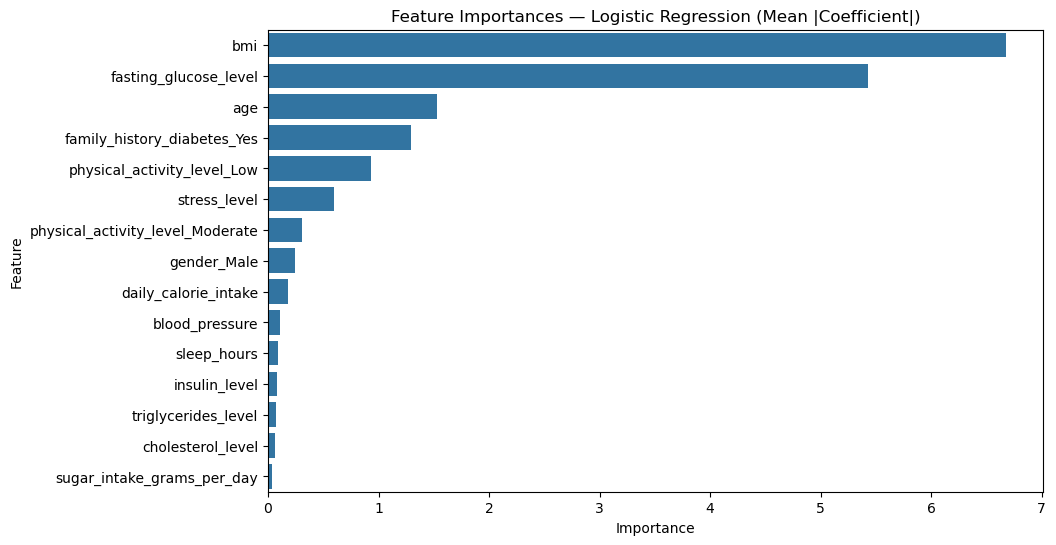

The Top 3 Features:
                 Feature  Importance
1                    bmi    6.677486
3  fasting_glucose_level    5.424001
0                    age    1.528778


In [25]:
# Feature importance 
importances_lr = np.abs(LR.coef_).mean(axis=0)

feature_importances_lr = pd.DataFrame({
    'Feature'   : train_X_std.columns,
    'Importance': importances_lr
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances_lr.head(20))
plt.title('Feature Importances — Logistic Regression (Mean |Coefficient|)')
plt.show()

print("The Top 3 Features:")
print(feature_importances_lr.head(3))

## Naive Bayes Classifier

In [26]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# Create Gaussian Naive Bayes classifier
gnb = GaussianNB()

# Fit on standardized training data
gnb.fit(train_X_std, y_train)

y_pred_nb  = gnb.predict(test_X_std)
y_proba_nb = gnb.predict_proba(test_X_std)

# Print first 10 predicted probabilities 
print(f"Estimated Probabilities:\n{y_proba_nb[:10]}")

acc_nb = accuracy_score(y_test, y_pred_nb)
print(f"\nAccuracy: {acc_nb}\n")

auc_nb = roc_auc_score(y_test, y_proba_nb, multi_class="ovr", average="macro")
print(f"Area Under ROC curve (AUC): {auc_nb}\n")

confusion_mat_nb = confusion_matrix(y_test, y_pred_nb)
print("Confusion Matrix:\n", confusion_mat_nb)
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))

Estimated Probabilities:
[[1.00000000e+00 5.64045478e-55 3.42218776e-21]
 [1.27612743e-01 2.02089225e-04 8.72185167e-01]
 [1.00000000e+00 3.64244651e-79 2.81804311e-30]
 [9.99996079e-01 3.29767462e-18 3.92133617e-06]
 [9.11522830e-01 5.52644664e-10 8.84771699e-02]
 [9.99959940e-01 6.65466866e-20 4.00596913e-05]
 [2.18400793e-10 9.99632638e-01 3.67362138e-04]
 [1.87418973e-01 4.36797541e-04 8.12144229e-01]
 [1.00000000e+00 4.81559134e-46 1.40360781e-15]
 [2.73597661e-07 1.29801927e-05 9.99986746e-01]]

Accuracy: 0.8383333333333334

Area Under ROC curve (AUC): 0.9458672011180532

Confusion Matrix:
 [[406   0  63]
 [  7 440  59]
 [ 41  24 160]]

Classification Report:
               precision    recall  f1-score   support

   High Risk       0.89      0.87      0.88       469
    Low Risk       0.95      0.87      0.91       506
 Prediabetes       0.57      0.71      0.63       225

    accuracy                           0.84      1200
   macro avg       0.80      0.82      0.81      1200

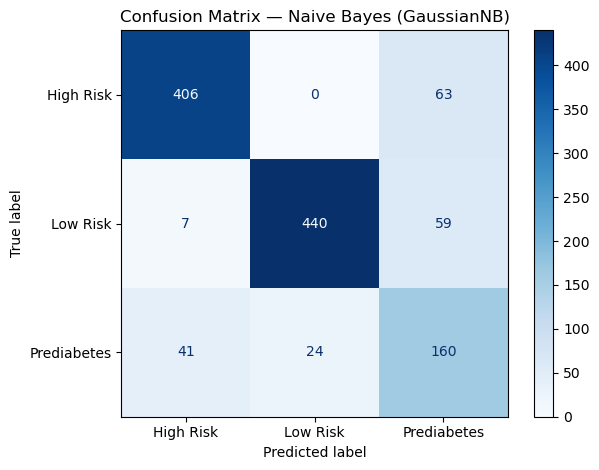

Train AUC: 0.9466  |  Test AUC: 0.9459
Train Accuracy: 0.829
Test Accuracy:  0.838


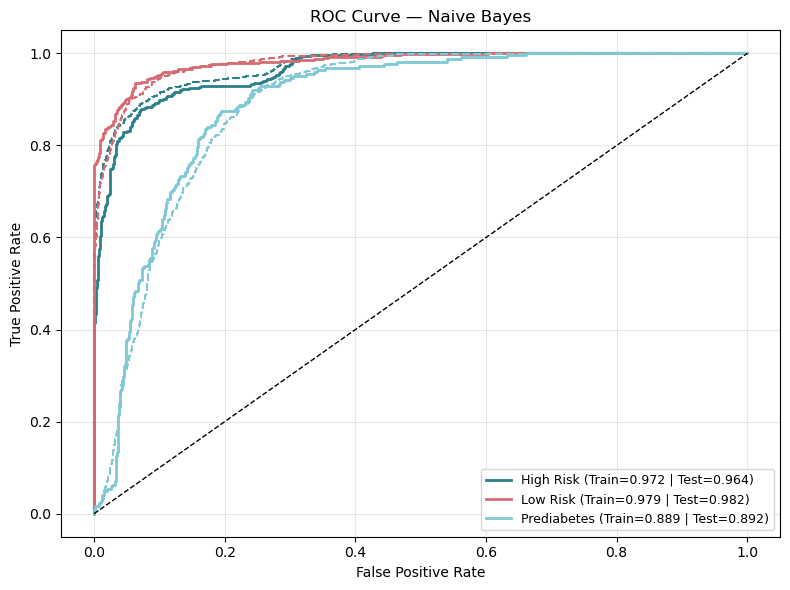

In [27]:
# Visualise Confusion Matrix — Naive Bayes
metrics.ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_nb,
    display_labels=gnb.classes_,
    cmap='Blues'
)
plt.title("Confusion Matrix — Naive Bayes (GaussianNB)")
plt.tight_layout()
plt.show()

# ROC Curve — Naive Bayes
multiclass_roc_curve(gnb, train_X_std, y_train, test_X_std, y_test, model_name="Naive Bayes")

In [28]:
from sklearn.metrics import precision_score, recall_score

# sensitivity 
sensitivity = recall_score(y_test, y_pred_nb, average='macro', zero_division=0)

# precision
precision = precision_score(y_test, y_pred_nb, average='macro', zero_division=0)

# specificity 
import numpy as np
cm = confusion_mat_nb
specificity_per_class = []
for i in range(len(cm)):
    tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
    fp = cm[:, i].sum() - cm[i, i]
    specificity_per_class.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
specificity = np.mean(specificity_per_class)

print(f"sensitivity (macro recall)  : {sensitivity:.4f}")
print(f"specificity (macro)         : {specificity:.4f}")
print(f"precision (macro)           : {precision:.4f}")
print(classification_report(y_test, y_pred_nb))

sensitivity (macro recall)  : 0.8154
specificity (macro)         : 0.9249
precision (macro)           : 0.8033
              precision    recall  f1-score   support

   High Risk       0.89      0.87      0.88       469
    Low Risk       0.95      0.87      0.91       506
 Prediabetes       0.57      0.71      0.63       225

    accuracy                           0.84      1200
   macro avg       0.80      0.82      0.81      1200
weighted avg       0.86      0.84      0.84      1200



## K-Nearest Neighbours (KNN)

#### Method 1: Without Hyperparameter Tuning (Default k=5)

Accuracy (k=5)    : 0.8441666666666666
AUC (OvR - macro) : 0.9384165315473155
Confusion Matrix:
 [[426   2  41]
 [  2 462  42]
 [ 52  48 125]]

Classification Report:
               precision    recall  f1-score   support

   High Risk       0.89      0.91      0.90       469
    Low Risk       0.90      0.91      0.91       506
 Prediabetes       0.60      0.56      0.58       225

    accuracy                           0.84      1200
   macro avg       0.80      0.79      0.79      1200
weighted avg       0.84      0.84      0.84      1200



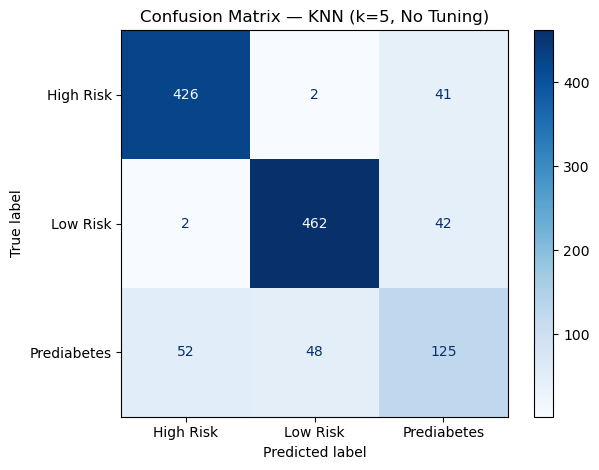

Train AUC: 0.9806  |  Test AUC: 0.9384
Train Accuracy: 0.906
Test Accuracy:  0.844


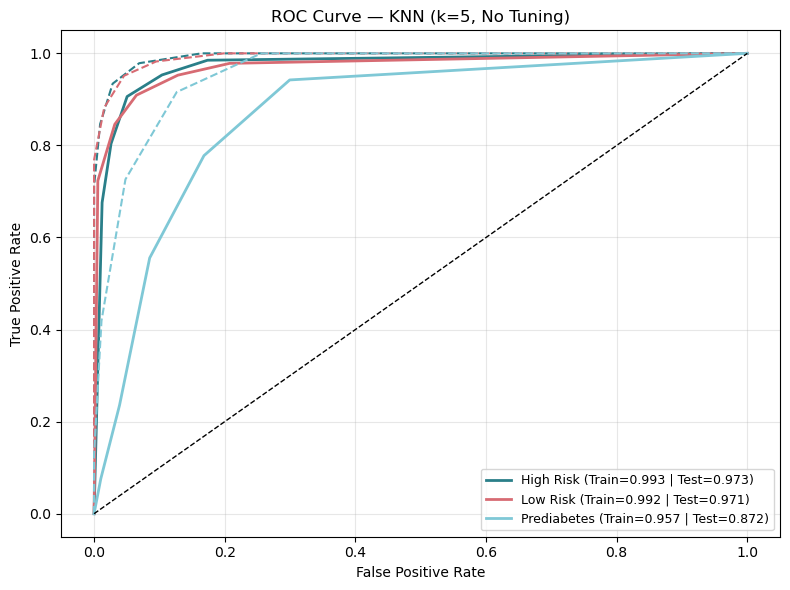

In [29]:
from sklearn.neighbors import KNeighborsClassifier

# Create KNN classifier with default k=5
knn_base = KNeighborsClassifier(n_neighbors=5)

# Fit on standardized training data
knn_base.fit(train_X_std, y_train)

y_pred_knn_base = knn_base.predict(test_X_std)
proba_knn_base  = knn_base.predict_proba(test_X_std)

acc_knn_base = metrics.accuracy_score(y_test, y_pred_knn_base)
auc_knn_base = metrics.roc_auc_score(
    y_test, proba_knn_base, multi_class='ovr', average='macro'
)

print(f"Accuracy (k=5)    : {acc_knn_base}")
print(f"AUC (OvR - macro) : {auc_knn_base}")
print("Confusion Matrix:\n", metrics.confusion_matrix(y_test, y_pred_knn_base))
print("\nClassification Report:\n", metrics.classification_report(y_test, y_pred_knn_base))

metrics.ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_knn_base,
    display_labels=knn_base.classes_,
    cmap='Blues'
)
plt.title("Confusion Matrix — KNN (k=5, No Tuning)")
plt.tight_layout()
plt.show()

# ROC Curve — KNN no tuning
multiclass_roc_curve(knn_base, train_X_std, y_train, test_X_std, y_test, model_name="KNN (k=5, No Tuning)")

#### Method 2: With Hyperparameter Tuning (GridSearchCV)

In [30]:
import time
import random
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

# Hyperparameter grid
param_grid_knn = {
    'n_neighbors': np.arange(5, 31, 5),
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['euclidean', 'manhattan']
}

gs_KNN = GridSearchCV(
    estimator=knn,
    param_grid=param_grid_knn,
    cv=5,
    return_train_score=True,
    scoring='roc_auc_ovr',
    n_jobs=-1,
    verbose=0
)

start_time = time.time()
random.seed(42)
gs_KNN.fit(train_X_std, y_train)
print(f"GridSearchCV completed in {time.time() - start_time:.1f}s")

m_knn = gs_KNN.best_estimator_
print("\nBest hyperparameters:")
print(f"  n_neighbors : {gs_KNN.best_params_['n_neighbors']}")
print(f"  weights     : {gs_KNN.best_params_['weights']}")
print(f"  metric      : {gs_KNN.best_params_['metric']}")
print(f"\nBest CV ROC AUC (OvR, 5-fold): {gs_KNN.best_score_:.4f}")


GridSearchCV completed in 4.9s

Best hyperparameters:
  n_neighbors : 20
  weights     : distance
  metric      : manhattan

Best CV ROC AUC (OvR, 5-fold): 0.9659


Training ROC AUC score (OvR, macro): 1.0
Testing ROC AUC score (OvR, macro): 0.9619601957350089
Train Accuracy: 1.000
Test Accuracy:  0.867
Train Precision (macro): 1.000
Test Precision (macro):  0.827
Train Recall (macro): 1.000
Test Recall (macro):  0.826
Train F1 Score (macro): 1.000
Test F1 Score (macro):  0.826

Confusion Matrix (Test):
 [[424   1  44]
 [  1 472  33]
 [ 37  44 144]]

Classification Report (Test):
               precision    recall  f1-score   support

   High Risk       0.92      0.90      0.91       469
    Low Risk       0.91      0.93      0.92       506
 Prediabetes       0.65      0.64      0.65       225

    accuracy                           0.87      1200
   macro avg       0.83      0.83      0.83      1200
weighted avg       0.87      0.87      0.87      1200



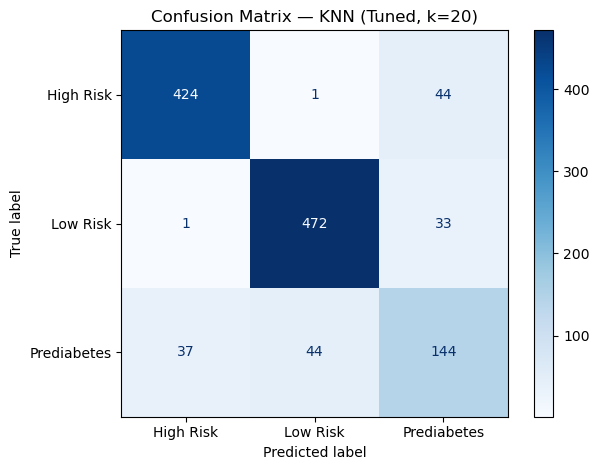

In [31]:
# Full evaluation — Train vs Test
classification_evaluation(m_knn, train_X_std, y_train, test_X_std, y_test, threshold=0.5)

# Confusion Matrix — KNN Tuned (k=20)
y_pred_knn_tuned = m_knn.predict(test_X_std)
metrics.ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_knn_tuned,
    display_labels=m_knn.classes_,
    cmap='Blues'
)
plt.title(f"Confusion Matrix — KNN (Tuned, k={gs_KNN.best_params_['n_neighbors']})")
plt.tight_layout()
plt.show()


Train AUC: 1.0000  |  Test AUC: 0.9620
Train Accuracy: 1.000
Test Accuracy:  0.867


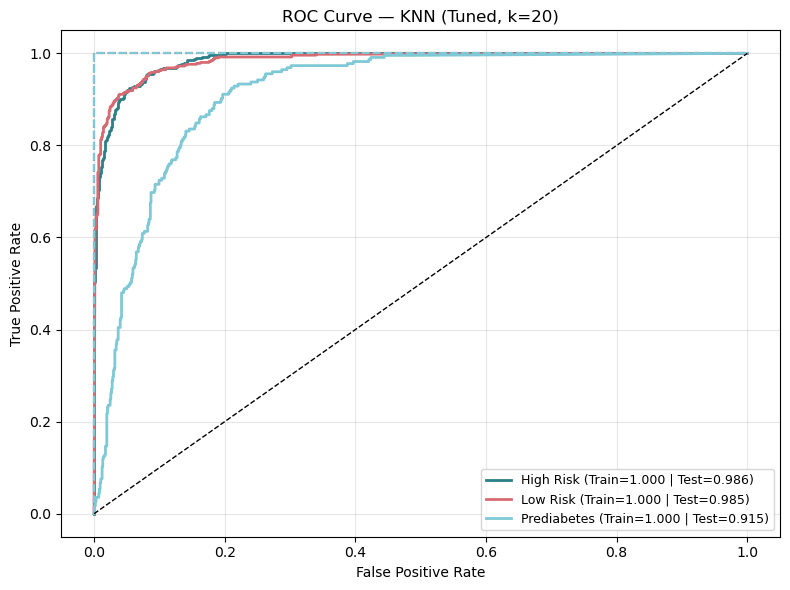

In [32]:
# ROC Curve — KNN tuned
multiclass_roc_curve(m_knn, train_X_std, y_train, test_X_std, y_test, model_name="KNN (Tuned, k=20)")

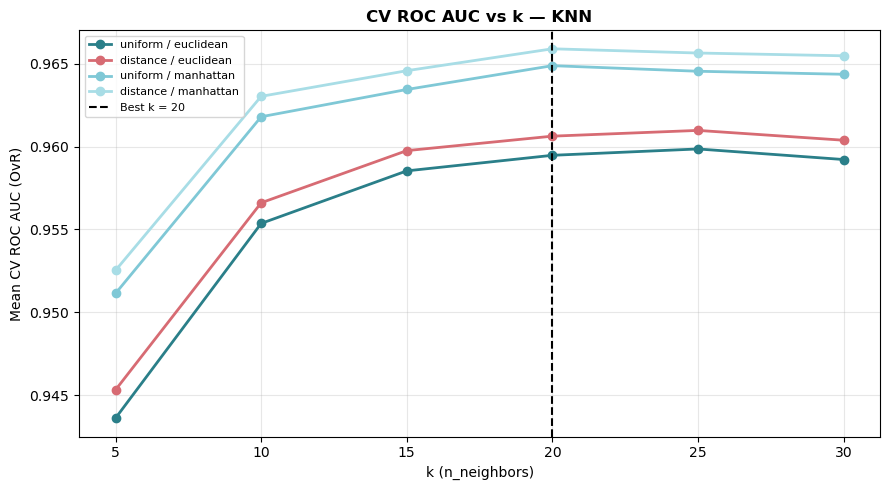

In [33]:
# Plot CV ROC AUC vs k for each weight / metric combination
cv_res = pd.DataFrame(gs_KNN.cv_results_)

plt.figure(figsize=(9, 5))
colors_knn = ['#2A7F89', '#D76B73', '#7FC8D6', '#A8DDE6']
combos = cv_res[['param_weights', 'param_metric']].drop_duplicates()

for i, (_, row) in enumerate(combos.iterrows()):
    mask = ((cv_res['param_weights'] == row['param_weights']) &
            (cv_res['param_metric']  == row['param_metric']))
    subset = cv_res[mask].sort_values('param_n_neighbors')
    plt.plot(
        subset['param_n_neighbors'].astype(int),
        subset['mean_test_score'],
        marker='o', linewidth=2,
        color=colors_knn[i % 4],
        label=f"{row['param_weights']} / {row['param_metric']}"
    )

plt.axvline(gs_KNN.best_params_['n_neighbors'], color='black', linestyle='--',
            label=f"Best k = {gs_KNN.best_params_['n_neighbors']}")
plt.title("CV ROC AUC vs k — KNN", fontweight='bold')
plt.xlabel("k (n_neighbors)")
plt.ylabel("Mean CV ROC AUC (OvR)")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Decision Tree & Ensembles
#### Tree-based models (Random Forest, and Gradient Boosting) were trained on raw feature values, as these algorithms are scale-invariant and do not require standardization.

In [34]:
import pandas as pd
import numpy as np
import random
import seaborn as sns
import matplotlib.pyplot as plt

### Decision Tree Classifier

In [35]:
# Import a Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
import time

# Import the GreadSearchCV class
from sklearn.model_selection import GridSearchCV

# Create a Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=42)

# Define the hyperparameters to tune
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': np.arange(3,10,1),
    'min_samples_split': [10, 15, 20],
    'min_samples_leaf': [5, 8, 10]
}

# Create a GridSearchCV object
gs = GridSearchCV(estimator=dt,
                  param_grid=param_grid, 
                  cv=5, 
                  return_train_score=True,
                  scoring= 'roc_auc_ovr',
                  n_jobs=-1, verbose=0)

start_time = time.time()

# Fit the GridSearchCV object on the training data
random.seed(42)
gs.fit(X_train, y_train)

print("--- %s seconds ---" % (time.time() - start_time))

m_cart = gs.best_estimator_

# Display the best hyperparameters
print("Best hyperparameters:", gs.best_params_)
print("Best CV ROC AUC (OvR):", gs.best_score_)

--- 1.9331541061401367 seconds ---
Best hyperparameters: {'criterion': 'gini', 'max_depth': np.int64(7), 'min_samples_leaf': 10, 'min_samples_split': 10}
Best CV ROC AUC (OvR): 0.9656488000402149


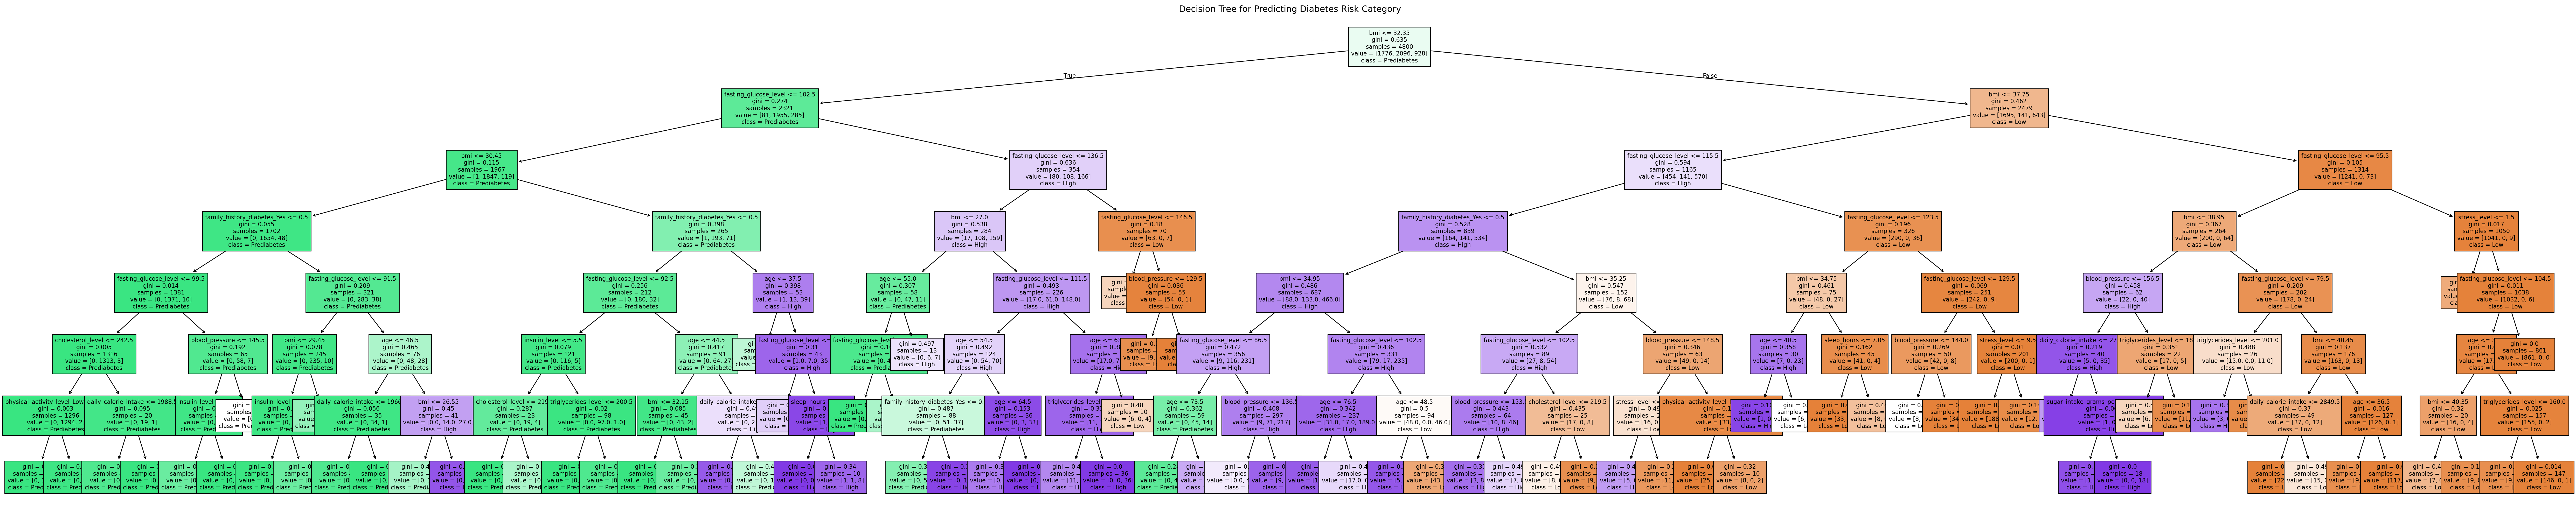

In [36]:
from sklearn.tree import plot_tree

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(50,10), dpi=200)

plot_tree(
    m_cart,
    feature_names=X_train.columns,
    class_names=['Low', 'Prediabetes', 'High'],
    filled=True,
    fontsize=8
)

plt.title("Decision Tree for Predicting Diabetes Risk Category")
plt.tight_layout()
plt.savefig("decision_tree_diabetes_risk.png", bbox_inches='tight', dpi=300)
plt.show()


In [37]:
classification_evaluation(m_cart, X_train, y_train, X_test, y_test, threshold=0.5)

Training ROC AUC score (OvR, macro): 0.9865532406353696
Testing ROC AUC score (OvR, macro): 0.9660156632337707
Train Accuracy: 0.922
Test Accuracy:  0.894
Train Precision (macro): 0.899
Test Precision (macro):  0.863
Train Recall (macro): 0.905
Test Recall (macro):  0.864
Train F1 Score (macro): 0.902
Test F1 Score (macro):  0.864

Confusion Matrix (Test):
 [[440   0  29]
 [  2 470  34]
 [ 30  32 163]]

Classification Report (Test):
               precision    recall  f1-score   support

   High Risk       0.93      0.94      0.94       469
    Low Risk       0.94      0.93      0.93       506
 Prediabetes       0.72      0.72      0.72       225

    accuracy                           0.89      1200
   macro avg       0.86      0.86      0.86      1200
weighted avg       0.89      0.89      0.89      1200



Train AUC: 0.9866  |  Test AUC: 0.9660
Train Accuracy: 0.922
Test Accuracy:  0.894


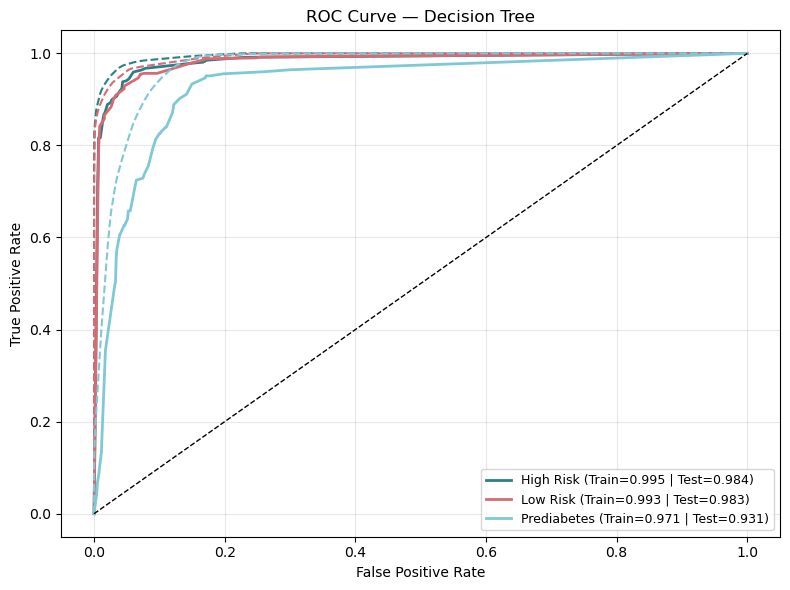

In [38]:
multiclass_roc_curve(m_cart, X_train, y_train, X_test, y_test, model_name="Decision Tree")

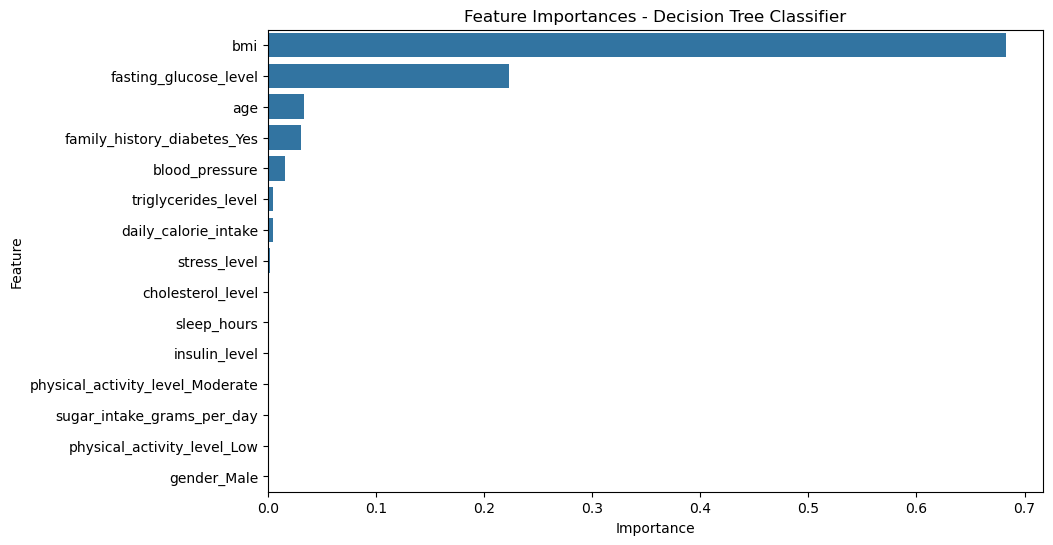

The Top 3 Features:
                 Feature  Importance
1                    bmi    0.682955
3  fasting_glucose_level    0.223223
0                    age    0.033640


In [39]:
# Create a feature importance for the random forest model
importances = m_cart.feature_importances_

# Create a DataFrame for the feature importances
feature_importances_cart = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances})

# Sort the DataFrame by importance
feature_importances_cart = feature_importances_cart.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances_cart.head(20))
plt.title('Feature Importances - Decision Tree Classifier')
plt.show()

# Display top 3 Features
print("The Top 3 Features:")
print(feature_importances_cart.head(3))

### Random Forest Classifier

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import time

param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": list(range(3, 10, 1)),
    "min_samples_leaf": [2, 5, 10],
    "criterion": ["gini", "entropy"]
}

rf = RandomForestClassifier(random_state=42)

gs_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=5,
    return_train_score=True,
    scoring="roc_auc_ovr",
    n_jobs=-1,
    verbose=0
)

start_time = time.time()

# Use UNSTANDARDIZED data
gs_rf.fit(X_train, y_train)

print("--- %s seconds ---" % (time.time() - start_time))

m_rf = gs_rf.best_estimator_
print("Best parameters:", gs_rf.best_params_)
print("Best CV ROC AUC (OvR):", gs_rf.best_score_)

--- 48.342233180999756 seconds ---
Best parameters: {'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 2, 'n_estimators': 300}
Best CV ROC AUC (OvR): 0.9801361318600932


In [41]:
classification_evaluation(m_rf, X_train, y_train, X_test, y_test, threshold=0.5)

Training ROC AUC score (OvR, macro): 0.9989011585757234
Testing ROC AUC score (OvR, macro): 0.980324042562014
Train Accuracy: 0.977
Test Accuracy:  0.905
Train Precision (macro): 0.972
Test Precision (macro):  0.877
Train Recall (macro): 0.970
Test Recall (macro):  0.877
Train F1 Score (macro): 0.971
Test F1 Score (macro):  0.877

Confusion Matrix (Test):
 [[438   0  31]
 [  0 479  27]
 [ 26  30 169]]

Classification Report (Test):
               precision    recall  f1-score   support

   High Risk       0.94      0.93      0.94       469
    Low Risk       0.94      0.95      0.94       506
 Prediabetes       0.74      0.75      0.75       225

    accuracy                           0.91      1200
   macro avg       0.88      0.88      0.88      1200
weighted avg       0.91      0.91      0.91      1200



Train AUC: 0.9989  |  Test AUC: 0.9803
Train Accuracy: 0.977
Test Accuracy:  0.905


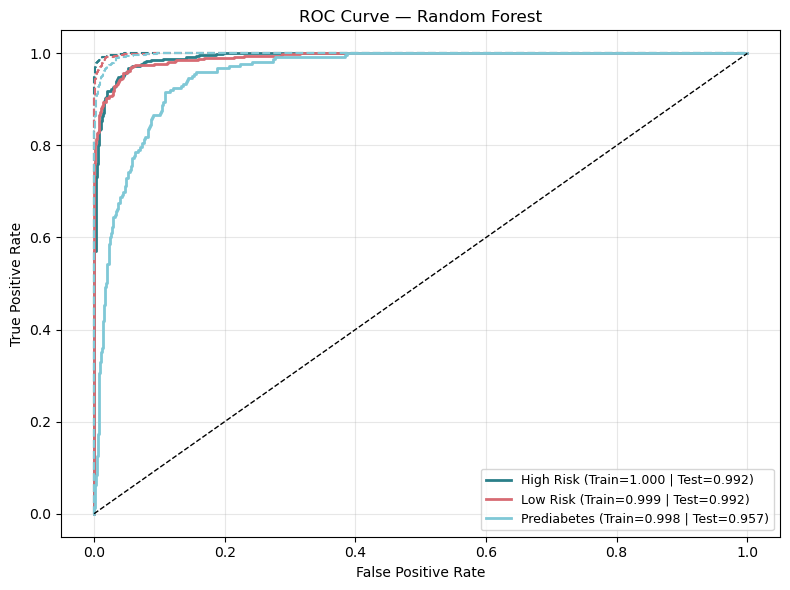

In [42]:
multiclass_roc_curve(m_rf, X_train, y_train, X_test, y_test, model_name="Random Forest")

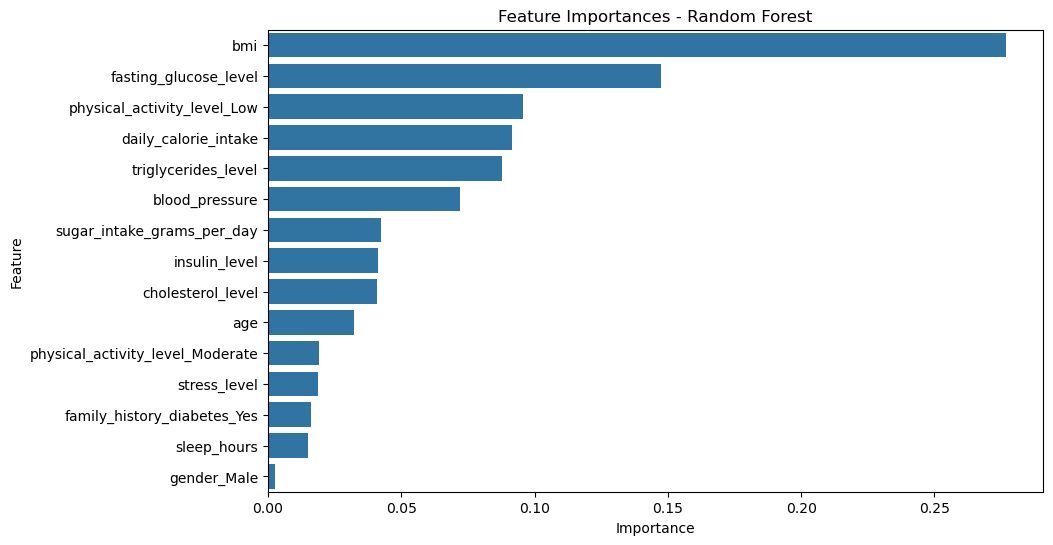

The Top 3 Features:
                        Feature  Importance
1                           bmi    0.276879
3         fasting_glucose_level    0.147404
12  physical_activity_level_Low    0.095700


In [43]:
# Create a feature importance for the random forest model
importances_rf = m_rf.feature_importances_

# Create a DataFrame for the feature importances
feature_importances_rf = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances_rf})

# Sort the DataFrame by importance
feature_importances_rf = feature_importances_rf.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances_rf.head(20))
plt.title('Feature Importances - Random Forest')
plt.show()

# Display top 3 Features
print("The Top 3 Features:")
print(feature_importances_rf.head(3))

### Gradient Boosting Classifier

In [44]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
import numpy as np
import time

param_grid_gbc = {
    "n_estimators": [100, 200, 300],
    "max_depth": np.arange(2, 6),
    "learning_rate": [0.05, 0.1, 0.2],
}

gbc = GradientBoostingClassifier(random_state=42)

gs_gbc = GridSearchCV(
    estimator=gbc,
    param_grid=param_grid_gbc,
    cv=5,
    scoring="roc_auc_ovr",
    return_train_score=True,
    n_jobs=-1,
    verbose=0
)

start_time = time.time()
gs_gbc.fit(X_train, y_train)
print("--- %s seconds ---" % (time.time() - start_time))

m_gbc = gs_gbc.best_estimator_
print("Best GBC parameters:", gs_gbc.best_params_)
print("Best CV ROC AUC (OvR):", gs_gbc.best_score_)

--- 120.26321578025818 seconds ---
Best GBC parameters: {'learning_rate': 0.2, 'max_depth': np.int64(2), 'n_estimators': 200}
Best CV ROC AUC (OvR): 0.9882501036931739


In [45]:
classification_evaluation(m_gbc, X_train, y_train, X_test, y_test, threshold=0.5)

Training ROC AUC score (OvR, macro): 0.9988782297390003
Testing ROC AUC score (OvR, macro): 0.9877524298163515
Train Accuracy: 0.979
Test Accuracy:  0.930
Train Precision (macro): 0.973
Test Precision (macro):  0.908
Train Recall (macro): 0.974
Test Recall (macro):  0.912
Train F1 Score (macro): 0.974
Test F1 Score (macro):  0.910

Confusion Matrix (Test):
 [[443   0  26]
 [  0 486  20]
 [ 18  20 187]]

Classification Report (Test):
               precision    recall  f1-score   support

   High Risk       0.96      0.94      0.95       469
    Low Risk       0.96      0.96      0.96       506
 Prediabetes       0.80      0.83      0.82       225

    accuracy                           0.93      1200
   macro avg       0.91      0.91      0.91      1200
weighted avg       0.93      0.93      0.93      1200



Train AUC: 0.9989  |  Test AUC: 0.9878
Train Accuracy: 0.979
Test Accuracy:  0.930


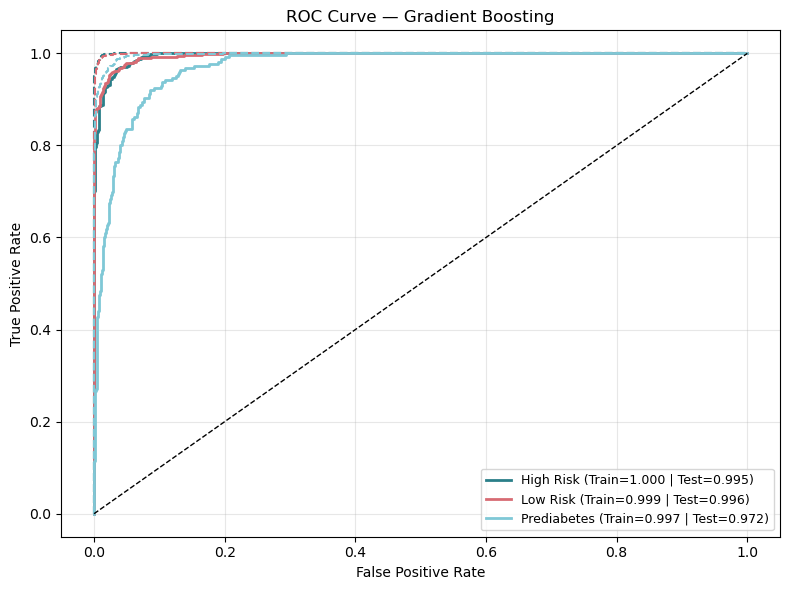

In [46]:
multiclass_roc_curve(m_gbc, X_train, y_train, X_test, y_test, model_name="Gradient Boosting")

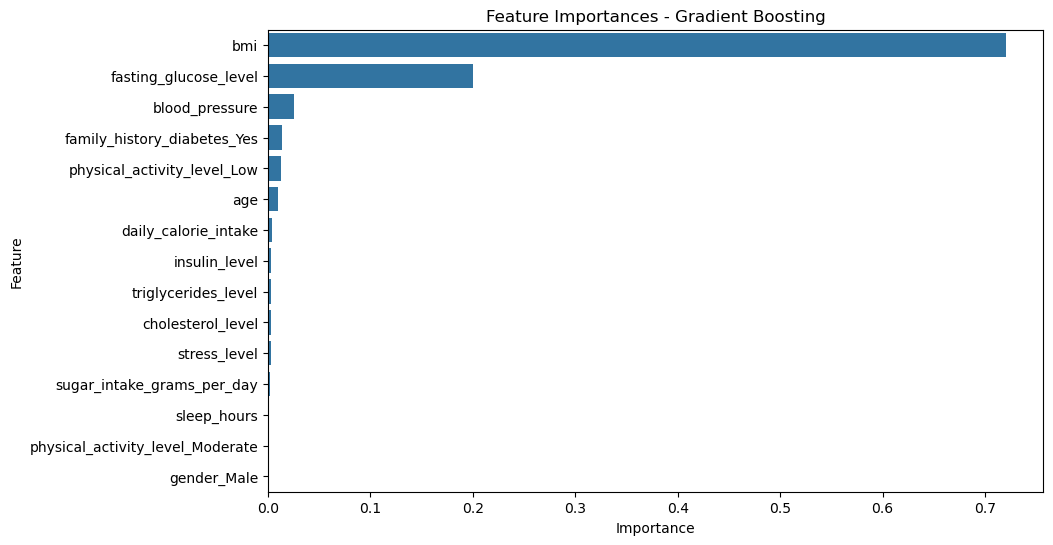

The Top 3 Features:
                 Feature  Importance
1                    bmi    0.720558
3  fasting_glucose_level    0.200486
2         blood_pressure    0.024917


In [47]:
# Create feature importance for Gradient Boosting model
importances_gbr = m_gbc.feature_importances_

# Create DataFrame
feature_importances_gbr = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances_gbr
})

# Sort by importance
feature_importances_gbr = feature_importances_gbr.sort_values(
    by='Importance',
    ascending=False
)

# Plot top 20 features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances_gbr.head(20))
plt.title('Feature Importances - Gradient Boosting')
plt.show()

# Display top 3 features
print("The Top 3 Features:")
print(feature_importances_gbr.head(3))


### XGBoost

In [48]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_xgb = le.fit_transform(y_train)  
y_test_xgb  = le.transform(y_test)

print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

Class mapping: {'High Risk': np.int64(0), 'Low Risk': np.int64(1), 'Prediabetes': np.int64(2)}


In [49]:
import sys
!{sys.executable} -m pip install xgboost

In [50]:
import xgboost as xgb
import numpy as np
import time
import random
from sklearn.model_selection import GridSearchCV

param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': np.arange(2, 6, 1),
}

xgb_clf = xgb.XGBClassifier(
    random_state=42,
    eval_metric='mlogloss'
)

gs_xgb = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid_xgb,
    cv=5,
    return_train_score=True,
    scoring='roc_auc_ovr',
    n_jobs=-1,
    verbose=0
)

random.seed(1)
start_time = time.time()
gs_xgb.fit(X_train, y_train_xgb)
print("--- %s seconds ---" % (time.time() - start_time))

m_xgb = gs_xgb.best_estimator_
print("Best parameters: ", gs_xgb.best_params_)
print("Best CV ROC AUC (OvR):", gs_xgb.best_score_)

--- 2.2127609252929688 seconds ---
Best parameters:  {'max_depth': np.int64(2), 'n_estimators': 200}
Best CV ROC AUC (OvR): 0.9886203632438157


In [51]:
y_pred_xgb_num = m_xgb.predict(X_test)
y_pred_xgb = le.inverse_transform(y_pred_xgb_num)

print(y_pred_xgb[:10])

['High Risk' 'High Risk' 'High Risk' 'High Risk' 'Prediabetes' 'High Risk'
 'Low Risk' 'High Risk' 'High Risk' 'High Risk']


In [52]:
def xgb_evaluation(model, X_train, y_train_xgb, X_test, y_test_xgb, label_encoder, threshold=0.5):
    from sklearn.metrics import (
        roc_auc_score, roc_curve, accuracy_score,
        precision_score, recall_score, f1_score,
        confusion_matrix, classification_report
    )
    from sklearn.preprocessing import label_binarize

    train_proba = model.predict_proba(X_train)
    test_proba  = model.predict_proba(X_test)
    y_pred_train = np.argmax(train_proba, axis=1)
    y_pred_test  = np.argmax(test_proba,  axis=1)
    classes      = np.arange(train_proba.shape[1])
    labels_str   = label_encoder.inverse_transform(classes)

    train_auc = roc_auc_score(y_train_xgb, train_proba, multi_class='ovr', average='macro')
    test_auc  = roc_auc_score(y_test_xgb,  test_proba,  multi_class='ovr', average='macro')

    print(f"Train AUC: {train_auc:.4f}  |  Test AUC: {test_auc:.4f}")
    print(f"Train Accuracy: {accuracy_score(y_train_xgb, y_pred_train):.3f}")
    print(f"Test Accuracy:  {accuracy_score(y_test_xgb,  y_pred_test):.3f}")
    print(f"Train Precision (macro): {precision_score(y_train_xgb, y_pred_train, average='macro', zero_division=0):.3f}")
    print(f"Test Precision (macro):  {precision_score(y_test_xgb,  y_pred_test,  average='macro', zero_division=0):.3f}")
    print(f"Train Recall (macro): {recall_score(y_train_xgb, y_pred_train, average='macro', zero_division=0):.3f}")
    print(f"Test Recall (macro):  {recall_score(y_test_xgb,  y_pred_test,  average='macro', zero_division=0):.3f}")
    print(f"Train F1 Score (macro): {f1_score(y_train_xgb, y_pred_train, average='macro', zero_division=0):.3f}")
    print(f"Test F1 Score (macro):  {f1_score(y_test_xgb,  y_pred_test,  average='macro', zero_division=0):.3f}")
    print("\nConfusion Matrix (Test):\n", confusion_matrix(y_test_xgb, y_pred_test))
    print("\nClassification Report (Test):\n", classification_report(y_test_xgb, y_pred_test, target_names=labels_str, zero_division=0))

    # ROC Curve — per class (same style as all other models)
    y_train_bin = label_binarize(y_train_xgb, classes=classes)
    y_test_bin  = label_binarize(y_test_xgb,  classes=classes)
    colors = ['#2A7F89', '#D76B73', '#7FC8D6']
    plt.figure(figsize=(8, 6))
    for i, (cls, color) in enumerate(zip(labels_str, colors)):
        fpr_tr, tpr_tr, _ = roc_curve(y_train_bin[:, i], train_proba[:, i])
        fpr_te, tpr_te, _ = roc_curve(y_test_bin[:, i],  test_proba[:, i])
        auc_tr = roc_auc_score(y_train_bin[:, i], train_proba[:, i])
        auc_te = roc_auc_score(y_test_bin[:, i],  test_proba[:, i])
        plt.plot(fpr_tr, tpr_tr, color=color, linestyle='--', linewidth=1.5)
        plt.plot(fpr_te, tpr_te, color=color, linestyle='-',  linewidth=2,
                 label=f"{cls} (Train={auc_tr:.3f} | Test={auc_te:.3f})")
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve — XGBoost")
    plt.legend(loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.show()


Train AUC: 0.9991  |  Test AUC: 0.9888
Train Accuracy: 0.981
Test Accuracy:  0.933
Train Precision (macro): 0.977
Test Precision (macro):  0.912
Train Recall (macro): 0.976
Test Recall (macro):  0.917
Train F1 Score (macro): 0.976
Test F1 Score (macro):  0.914

Confusion Matrix (Test):
 [[448   0  21]
 [  0 483  23]
 [ 17  19 189]]

Classification Report (Test):
               precision    recall  f1-score   support

   High Risk       0.96      0.96      0.96       469
    Low Risk       0.96      0.95      0.96       506
 Prediabetes       0.81      0.84      0.83       225

    accuracy                           0.93      1200
   macro avg       0.91      0.92      0.91      1200
weighted avg       0.93      0.93      0.93      1200



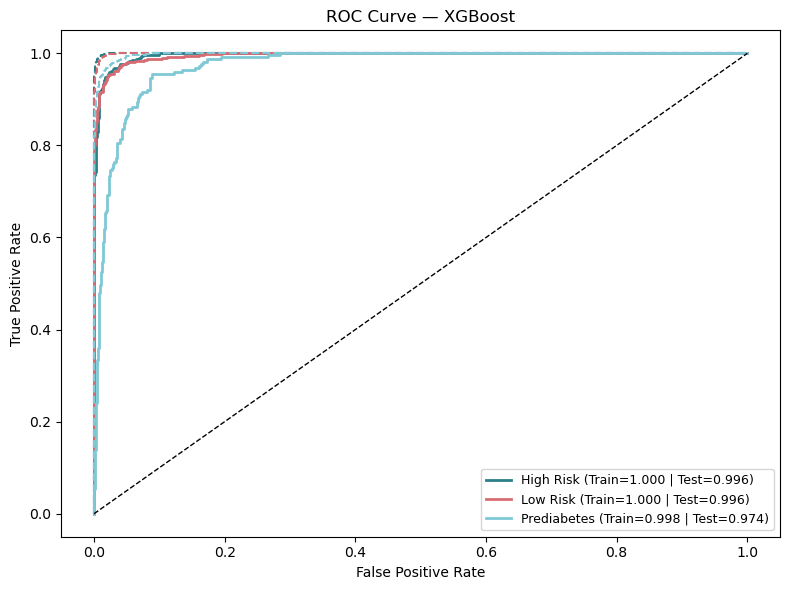

In [53]:
xgb_evaluation(m_xgb, X_train, y_train_xgb, X_test, y_test_xgb, label_encoder=le)

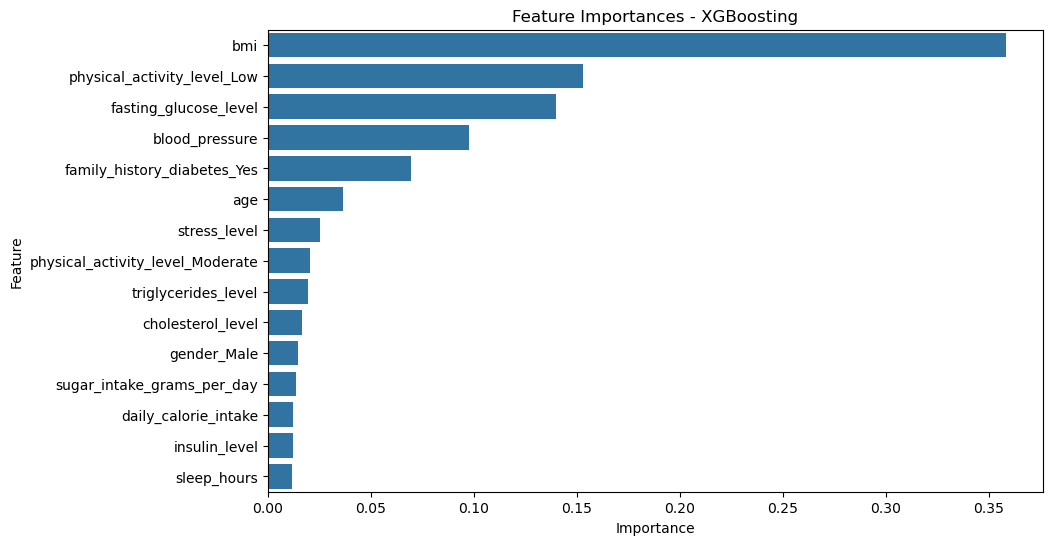

The Top 3 Features:
                        Feature  Importance
1                           bmi    0.358551
12  physical_activity_level_Low    0.152913
3         fasting_glucose_level    0.139658


In [54]:
# Create feature importance for Gradient Boosting model
importances_xg = m_xgb.feature_importances_

# Create DataFrame
feature_importances_xg = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances_xg
})

# Sort by importance
feature_importances_xg = feature_importances_xg.sort_values(
    by='Importance',
    ascending=False
)

# Plot top 20 features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances_xg.head(20))
plt.title('Feature Importances - XGBoosting')
plt.show()

# Display top 3 features
print("The Top 3 Features:")
print(feature_importances_xg.head(3))


### LightGBM

In [55]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [56]:
import lightgbm as lgb
import numpy as np
import time
import random
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid_lgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': np.arange(2, 6, 1),
}

# Create GridSearchCV object
gs_lgb = GridSearchCV(
    estimator=lgb.LGBMClassifier(random_state=42, verbose=-1),
    param_grid=param_grid_lgb,
    cv=5,
    return_train_score=True,
    scoring='roc_auc_ovr',   # multiclass ROC-AUC
    n_jobs=-1,
    verbose=0
)

# Fit the model
random.seed(1)
start_time = time.time()
gs_lgb.fit(X_train, y_train)
print("--- %s seconds ---" % (time.time() - start_time))

# Best model
m_lgb = gs_lgb.best_estimator_

print("Best LGB parameters:", gs_lgb.best_params_)
print("Best CV ROC AUC (OvR):", gs_lgb.best_score_)

--- 66.38817596435547 seconds ---
Best LGB parameters: {'max_depth': np.int64(2), 'n_estimators': 300}
Best CV ROC AUC (OvR): 0.9880840329258265


In [57]:
classification_evaluation(m_lgb, X_train, y_train, X_test, y_test, threshold=0.5)

Training ROC AUC score (OvR, macro): 0.9980668774520342
Testing ROC AUC score (OvR, macro): 0.988500787934532
Train Accuracy: 0.974
Test Accuracy:  0.930
Train Precision (macro): 0.966
Test Precision (macro):  0.908
Train Recall (macro): 0.967
Test Recall (macro):  0.913
Train F1 Score (macro): 0.967
Test F1 Score (macro):  0.910

Confusion Matrix (Test):
 [[447   0  22]
 [  0 481  25]
 [ 17  20 188]]

Classification Report (Test):
               precision    recall  f1-score   support

   High Risk       0.96      0.95      0.96       469
    Low Risk       0.96      0.95      0.96       506
 Prediabetes       0.80      0.84      0.82       225

    accuracy                           0.93      1200
   macro avg       0.91      0.91      0.91      1200
weighted avg       0.93      0.93      0.93      1200



Train AUC: 0.9981  |  Test AUC: 0.9885
Train Accuracy: 0.974
Test Accuracy:  0.930


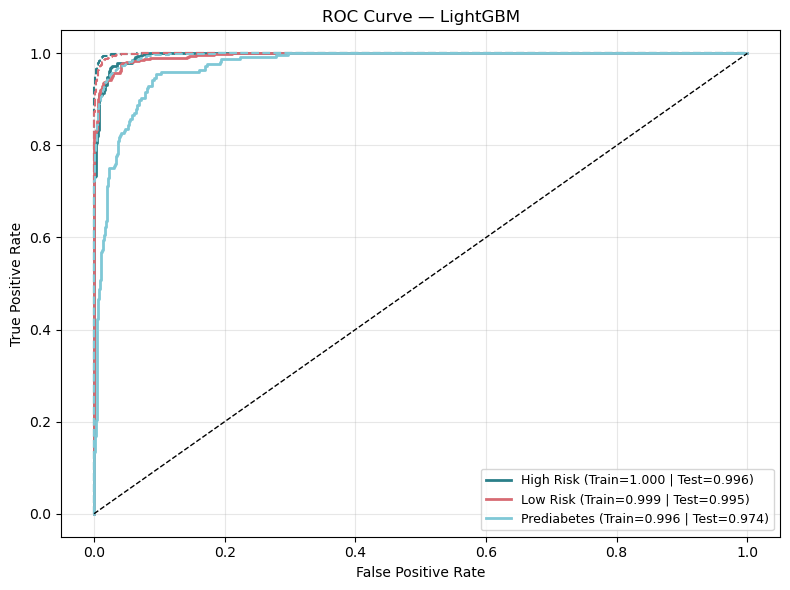

In [58]:
multiclass_roc_curve(m_lgb, X_train, y_train, X_test, y_test, model_name="LightGBM")

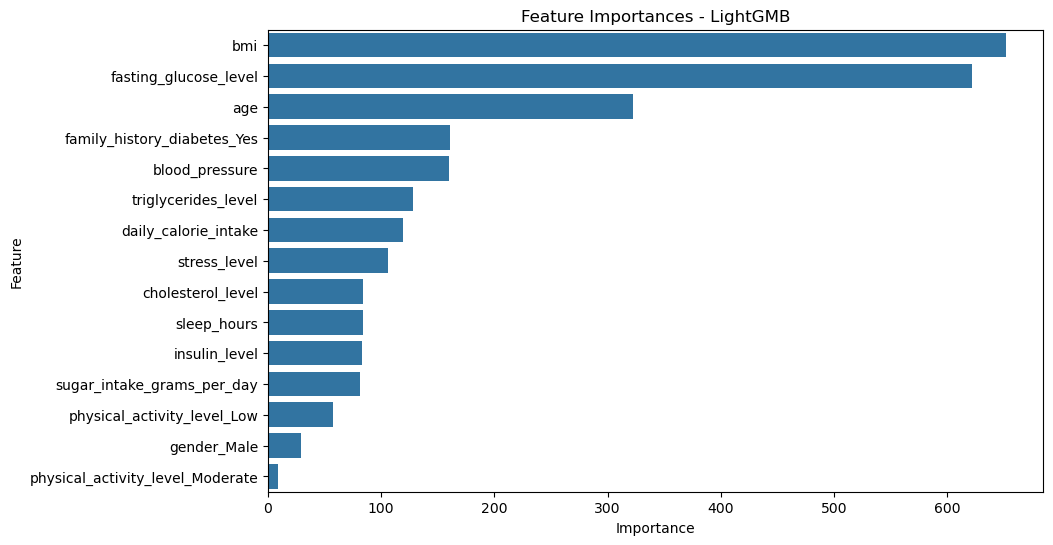

The Top 3 Features:
                 Feature  Importance
1                    bmi         652
3  fasting_glucose_level         622
0                    age         322


In [59]:
# Create feature importance for Gradient Boosting model
importances_lgb = m_lgb.feature_importances_

# Create DataFrame
feature_importances_lgb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances_lgb
})

# Sort by importance
feature_importances_lgb = feature_importances_lgb.sort_values(
    by='Importance',
    ascending=False
)

# Plot top 20 features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances_lgb.head(20))
plt.title('Feature Importances - LightGMB')
plt.show()

# Display top 3 features
print("The Top 3 Features:")
print(feature_importances_lgb.head(3))


## Neural Network (NN)

In [60]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics.pairwise import euclidean_distances

import matplotlib.pyplot as plt

In [61]:
from sklearn.preprocessing import LabelEncoder

# Convert to numpy arrays (recommended for ANN / RBFNN / PNN stability)
X_train_np = train_X_std.to_numpy(dtype=np.float64)
X_test_np  = test_X_std.to_numpy(dtype=np.float64)

# Encode target labels into integers (required for ROC-AUC multiclass OVR)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

class_names = list(le.classes_)
print("Classes:", class_names)

Classes: ['High Risk', 'Low Risk', 'Prediabetes']


In [62]:
# Model A: Train ANN (MLP)
ann = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=500,
    random_state=42,
    early_stopping=False   # keep False for fair comparison
)

ann.fit(X_train_np, y_train_enc)

MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)

### Radial Basis Function Neural Network (RBNN)

In [63]:
# Model B: RBFNN Classifier
class RBFNNClassifier:
    def __init__(self, n_centers=50, gamma=0.1, random_state=42):
        self.n_centers = n_centers
        self.gamma = gamma
        self.random_state = random_state
        self.kmeans = None
        self.clf = None
        self.classes_ = None

    def _rbf_features(self, X):
        D2 = euclidean_distances(X, self.kmeans.cluster_centers_, squared=True)
        return np.exp(-self.gamma * D2)

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.kmeans = KMeans(n_clusters=self.n_centers, random_state=self.random_state, n_init="auto")
        self.kmeans.fit(X)

        Phi = self._rbf_features(X)

        self.clf = LogisticRegression(
            max_iter=2000,
            multi_class="multinomial",
            class_weight="balanced"
        )
        self.clf.fit(Phi, y)
        return self

    def predict(self, X):
        Phi = self._rbf_features(X)
        return self.clf.predict(Phi)

    def predict_proba(self, X):
        Phi = self._rbf_features(X)
        return self.clf.predict_proba(Phi)

# Train
rbfnn = RBFNNClassifier(n_centers=50, gamma=0.1, random_state=42)
rbfnn.fit(X_train_np, y_train_enc)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


### Probabilistic Neural Network (PNN)

In [64]:
# Model C: PNN Classifier
class PNNClassifier:
    def __init__(self, sigma=0.5):
        self.sigma = sigma
        self.X_train_ = None
        self.y_train_ = None
        self.classes_ = None
        self.class_priors_ = None

    def fit(self, X, y):
        self.X_train_ = np.asarray(X, dtype=np.float64)
        self.y_train_ = np.asarray(y)
        self.classes_, counts = np.unique(self.y_train_, return_counts=True)
        self.class_priors_ = counts / counts.sum()
        return self

    def predict_proba(self, X):
        X = np.asarray(X, dtype=np.float64)
        D2 = euclidean_distances(X, self.X_train_, squared=True)

        K = np.exp(-D2 / (2 * (self.sigma ** 2)))

        proba = np.zeros((X.shape[0], len(self.classes_)), dtype=np.float64)
        for j, c in enumerate(self.classes_):
            mask = (self.y_train_ == c)
            proba[:, j] = K[:, mask].mean(axis=1) * self.class_priors_[j]

        row_sum = proba.sum(axis=1, keepdims=True)
        proba = np.divide(proba, row_sum, out=np.zeros_like(proba), where=row_sum != 0)
        return proba

    def predict(self, X):
        proba = self.predict_proba(X)
        return self.classes_[np.argmax(proba, axis=1)]

# Train
pnn = PNNClassifier(sigma=0.5)
pnn.fit(X_train_np, y_train_enc)


### Evaluation Function

In [65]:
# ============================================
# Evaluation Utilities (Train vs Test)
#     - Accuracy, Precision, Recall, F1 (macro)
#     - ROC-AUC (multiclass OVR macro)
# ============================================
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name="Model"):
    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)

    # probabilities for AUC (multiclass-safe)
    y_train_proba = model.predict_proba(X_train)
    y_test_proba  = model.predict_proba(X_test)

    print(f"\n{model_name} Performance")
    print("=" * 60)

    print("\nTraining Set:")
    print(f"  Accuracy:  {accuracy_score(y_train, y_train_pred):.4f}")
    print(f"  Precision: {precision_score(y_train, y_train_pred, average='macro', zero_division=0):.4f}")
    print(f"  Recall:    {recall_score(y_train, y_train_pred, average='macro', zero_division=0):.4f}")
    print(f"  F1-Score:  {f1_score(y_train, y_train_pred, average='macro', zero_division=0):.4f}")
    print(f"  ROC-AUC:   {roc_auc_score(y_train, y_train_proba, multi_class='ovr', average='macro'):.4f}")

    print("\nTest Set:")
    print(f"  Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
    print(f"  Precision: {precision_score(y_test, y_test_pred, average='macro', zero_division=0):.4f}")
    print(f"  Recall:    {recall_score(y_test, y_test_pred, average='macro', zero_division=0):.4f}")
    print(f"  F1-Score:  {f1_score(y_test, y_test_pred, average='macro', zero_division=0):.4f}")
    print(f"  ROC-AUC:   {roc_auc_score(y_test, y_test_proba, multi_class='ovr', average='macro'):.4f}")

    print("\nClassification Report (Test):")
    print(classification_report(y_test, y_test_pred, target_names=class_names, zero_division=0))

    return {
        "Model": model_name,
        "Test_Accuracy": accuracy_score(y_test, y_test_pred),
        "Test_F1_macro": f1_score(y_test, y_test_pred, average="macro", zero_division=0),
        "Test_AUC_macro": roc_auc_score(y_test, y_test_proba, multi_class="ovr", average="macro")
    }

In [66]:
results = []
results.append(evaluate_model(ann,   X_train_np, y_train_enc, X_test_np, y_test_enc, "ANN (MLP)"))
results.append(evaluate_model(rbfnn, X_train_np, y_train_enc, X_test_np, y_test_enc, "RBFNN"))
results.append(evaluate_model(pnn,   X_train_np, y_train_enc, X_test_np, y_test_enc, "PNN"))

comparison_df = pd.DataFrame(results).sort_values("Test_F1_macro", ascending=False)
comparison_df


ANN (MLP) Performance

Training Set:
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  ROC-AUC:   1.0000

Test Set:
  Accuracy:  0.9150
  Precision: 0.8893
  Recall:    0.8912
  F1-Score:  0.8903
  ROC-AUC:   0.9840

Classification Report (Test):
              precision    recall  f1-score   support

   High Risk       0.95      0.95      0.95       469
    Low Risk       0.94      0.94      0.94       506
 Prediabetes       0.77      0.78      0.78       225

    accuracy                           0.92      1200
   macro avg       0.89      0.89      0.89      1200
weighted avg       0.92      0.92      0.92      1200


RBFNN Performance

Training Set:
  Accuracy:  0.8627
  Precision: 0.8372
  Recall:    0.8548
  F1-Score:  0.8400
  ROC-AUC:   0.9689

Test Set:
  Accuracy:  0.8617
  Precision: 0.8335
  Recall:    0.8522
  F1-Score:  0.8364
  ROC-AUC:   0.9663

Classification Report (Test):
              precision    recall  f1-score   support

   High 

,Model,Test_Accuracy,Test_F1_macro,Test_AUC_macro
0,ANN (MLP),0.915000,0.890274,0.983964
1,RBFNN,0.861667,0.836391,0.966264
2,PNN,0.844167,0.797816,0.949677


### ROC Curves for 3 Models (Multiclass OVR)

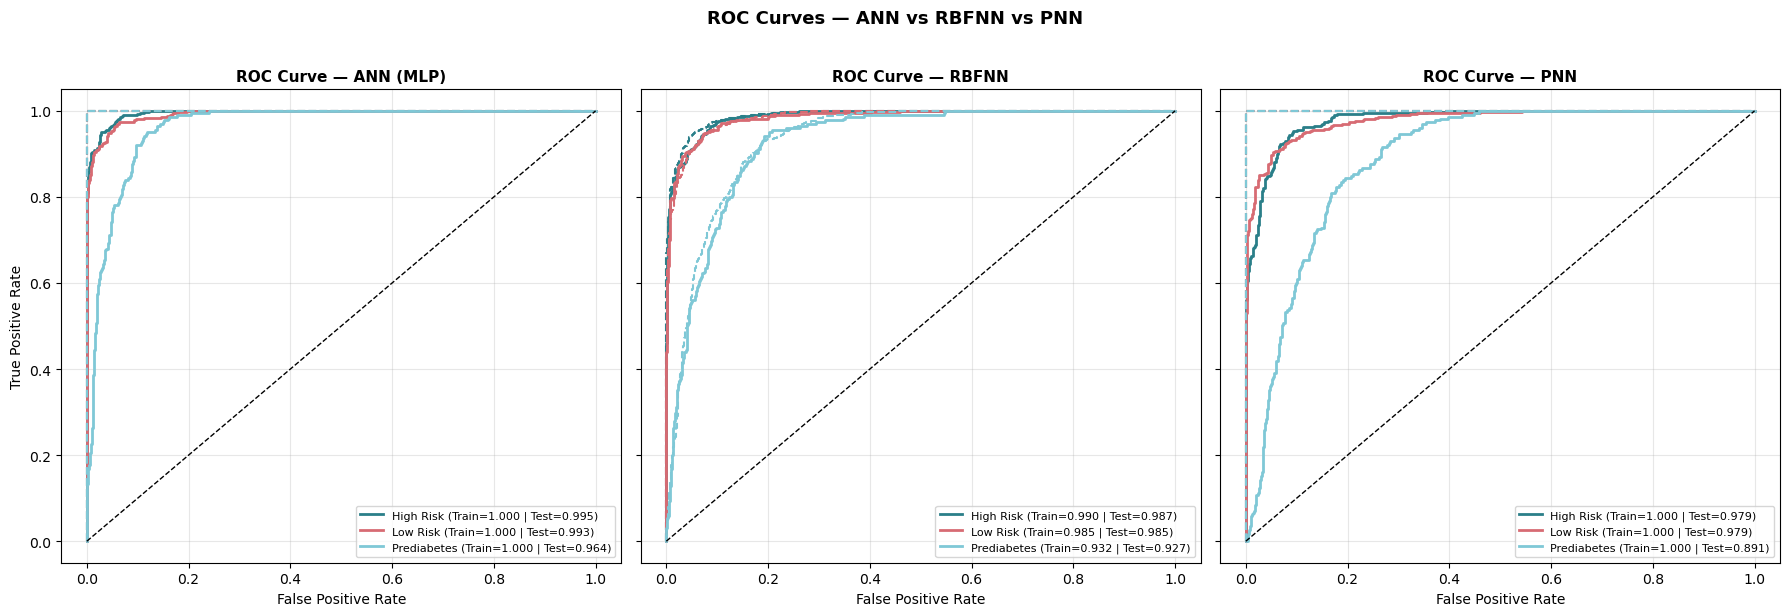

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

ROC_COLORS = ['#2A7F89', '#D76B73', '#7FC8D6']

classes      = np.unique(y_test_enc)
class_labels = list(le.classes_)

y_train_bin = label_binarize(y_train_enc, classes=classes)
y_test_bin  = label_binarize(y_test_enc,  classes=classes)

models_nn = {
    "ANN (MLP)": ann,
    "RBFNN":     rbfnn,
    "PNN":       pnn,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, (model_name, model) in zip(axes, models_nn.items()):
    train_proba = model.predict_proba(X_train_np)
    test_proba  = model.predict_proba(X_test_np)

    for i, (cls_label, color) in enumerate(zip(class_labels, ROC_COLORS)):
        fpr_tr, tpr_tr, _ = roc_curve(y_train_bin[:, i], train_proba[:, i])
        fpr_te, tpr_te, _ = roc_curve(y_test_bin[:, i],  test_proba[:, i])
        auc_tr = auc(fpr_tr, tpr_tr)
        auc_te = auc(fpr_te, tpr_te)

        ax.plot(fpr_tr, tpr_tr, color=color, linestyle='--', linewidth=1.5)
        ax.plot(fpr_te, tpr_te, color=color, linestyle='-',  linewidth=2,
                label=f"{cls_label} (Train={auc_tr:.3f} | Test={auc_te:.3f})")

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax.set_title(f"ROC Curve — {model_name}", fontsize=11, fontweight='bold')
    ax.set_xlabel("False Positive Rate")
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("True Positive Rate")
plt.suptitle("ROC Curves — ANN vs RBFNN vs PNN", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

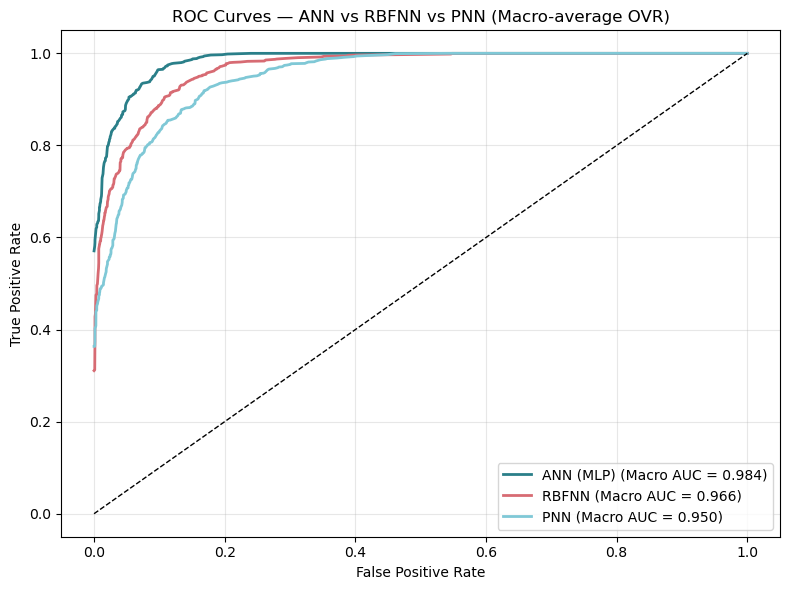

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

MODEL_COLORS = ['#2A7F89', '#D76B73', '#7FC8D6']

classes     = np.unique(y_test_enc)
n_classes   = len(classes)
y_test_bin  = label_binarize(y_test_enc, classes=classes)

models_nn = {
    "ANN (MLP)": ann,
    "RBFNN":     rbfnn,
    "PNN":       pnn,
}

plt.figure(figsize=(8, 6))

for (model_name, model), color in zip(models_nn.items(), MODEL_COLORS):
    test_proba = model.predict_proba(X_test_np)

    # Compute macro-average ROC
    all_fpr  = np.unique(np.concatenate([
        roc_curve(y_test_bin[:, i], test_proba[:, i])[0]
        for i in range(n_classes)
    ]))
    mean_tpr = np.zeros_like(all_fpr)
    macro_auc = 0

    for i in range(n_classes):
        fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], test_proba[:, i])
        mean_tpr  += np.interp(all_fpr, fpr_i, tpr_i)
        macro_auc += auc(fpr_i, tpr_i)

    mean_tpr  /= n_classes
    macro_auc /= n_classes

    plt.plot(all_fpr, mean_tpr, color=color, linewidth=2,
             label=f"{model_name} (Macro AUC = {macro_auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — ANN vs RBFNN vs PNN (Macro-average OVR)")
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Best model based on Test_F1_macro: ANN (MLP)


<Figure size 700x500 with 0 Axes>

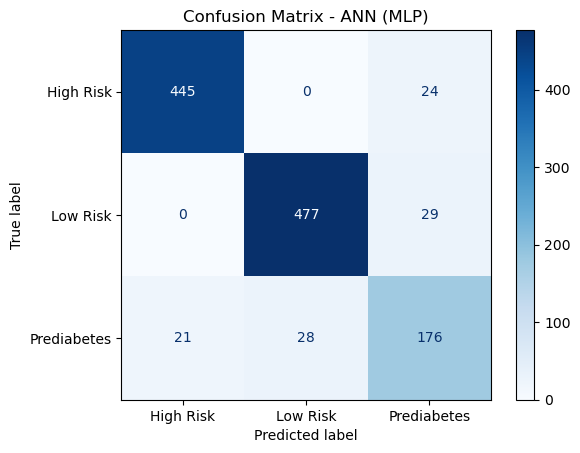

In [69]:
# Confusion Matrix for the best model
best_model_name = comparison_df.iloc[0]["Model"]
print("Best model based on Test_F1_macro:", best_model_name)

best_model = {"ANN (MLP)": ann, "RBFNN": rbfnn, "PNN": pnn}[best_model_name]
y_test_pred_best = best_model.predict(X_test_np)

cm = confusion_matrix(y_test_enc, y_test_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure(figsize=(7, 5))
disp.plot(values_format="d", cmap="Blues")   
plt.title(f"Confusion Matrix - {best_model_name}")
plt.grid(False)
plt.show()

## Support Vector Classification - Baseline

In [70]:
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve, auc
)

# Build SVM model (baseline)

# Notes:
# - RBF kernel is a strong default for non-linear boundaries
# - class_weight="balanced" helps if classes are imbalanced
svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced",
    probability=True,
    random_state=42
)

svm.fit(train_X_std, y_train_enc)

SVC(class_weight='balanced', probability=True, random_state=42)

In [71]:
# Evaluate the performance

# Make predictions with rbf
y_train_pred_svm = svm.predict(train_X_std)
y_test_pred_svm   = svm.predict(test_X_std)

# Probabilities: shape = (n_samples, n_classes)
y_train_proba_svm = svm.predict_proba(train_X_std)
y_test_proba_svm   = svm.predict_proba(test_X_std)

print("\nModel Performance Metrics (Train vs Test)")
print("="*60)

# Training performance
print("\nTraining Set:")
print(f"  Accuracy:  {accuracy_score(y_train_enc, y_train_pred_svm):.4f}")
print(f"  Precision: {precision_score(y_train_enc, y_train_pred_svm, average='macro', zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_train_enc, y_train_pred_svm, average='macro', zero_division=0):.4f}")
print(f"  F1-macro:  {f1_score(y_train_enc, y_train_pred_svm, average='macro', zero_division=0):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_train_enc, y_train_proba_svm, multi_class='ovr', average='macro'):.4f}")

# Test performance
print("\nTest Set:")
print(f"  Accuracy:  {accuracy_score(y_test_enc, y_test_pred_svm):.4f}")
print(f"  Precision: {precision_score(y_test_enc, y_test_pred_svm, average='macro', zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_test_enc, y_test_pred_svm, average='macro', zero_division=0):.4f}")
print(f"  F1-macro:  {f1_score(y_test_enc, y_test_pred_svm, average='macro', zero_division=0):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test_enc, y_test_proba_svm, multi_class='ovr', average='macro'):.4f}")


Model Performance Metrics (Train vs Test)

Training Set:
  Accuracy:  0.9385
  Precision: 0.9183
  Recall:    0.9419
  F1-macro:  0.9265
  ROC-AUC:   0.9947

Test Set:
  Accuracy:  0.9242
  Precision: 0.9004
  Recall:    0.9259
  F1-macro:  0.9085
  ROC-AUC:   0.9878



 Confusion Matrix (Test Set):
[[434   0  35]
 [  0 465  41]
 [  8   7 210]]


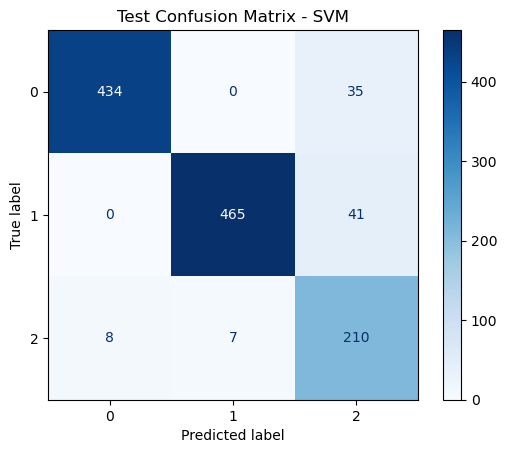

In [72]:
# Visualize the confusion matrix
print("\n Confusion Matrix (Test Set):")
cm_val = confusion_matrix(y_test_enc, y_test_pred_svm)
print(cm_val)
ConfusionMatrixDisplay(confusion_matrix=cm_val).plot(cmap='Blues')
plt.title("Test Confusion Matrix - SVM")
plt.show()


 ROC Curve Analysis:


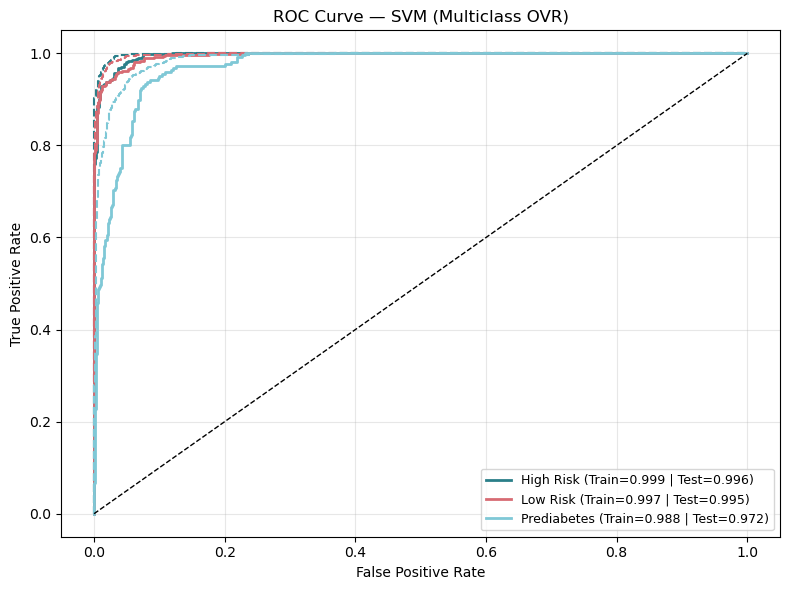

In [73]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

print("\n ROC Curve Analysis:")

# Shared color palette (same as all other ROC plots)
ROC_COLORS = ['#2A7F89', '#D76B73', '#7FC8D6']

# Binarize labels (use original string labels)
classes_svm = np.unique(y_train)
y_train_bin_svm = label_binarize(y_train, classes=classes_svm)
y_test_bin_svm  = label_binarize(y_test,  classes=classes_svm)

plt.figure(figsize=(8, 6))

for i, (class_label, color) in enumerate(zip(classes_svm, ROC_COLORS)):
    fpr_train, tpr_train, _ = roc_curve(y_train_bin_svm[:, i], y_train_proba_svm[:, i])
    fpr_test,  tpr_test,  _ = roc_curve(y_test_bin_svm[:, i],  y_test_proba_svm[:, i])
    auc_train = auc(fpr_train, tpr_train)
    auc_test  = auc(fpr_test,  tpr_test)

    plt.plot(fpr_train, tpr_train, color=color, linestyle='--', linewidth=1.5)
    plt.plot(fpr_test,  tpr_test,  color=color, linestyle='-',  linewidth=2,
             label=f"{class_label} (Train={auc_train:.3f} | Test={auc_test:.3f})")

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.title('ROC Curve — SVM (Multiclass OVR)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Cross-Validation

In [74]:
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_acc, cv_f1 = [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    X_tr = X.iloc[train_idx].copy()
    X_val = X.iloc[val_idx].copy()
    y_tr = y.iloc[train_idx].copy()
    y_val = y.iloc[val_idx].copy()

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_val_s = scaler.transform(X_val)

    clf = clone(svm)
    clf.fit(X_tr_s, y_tr)
    preds = clf.predict(X_val_s)

    acc = accuracy_score(y_val, preds)
    f1  = f1_score(y_val, preds, average="macro")

    cv_acc.append(acc)
    cv_f1.append(f1)

    print(f"Fold {fold}: Accuracy={acc:.4f}, F1-macro={f1:.4f}")

print("\nCV Accuracy:", np.round(cv_acc, 4))
print("Mean Acc:", np.mean(cv_acc).round(4), "Std:", np.std(cv_acc).round(4))
print("\nCV F1-macro:", np.round(cv_f1, 4))
print("Mean F1:", np.mean(cv_f1).round(4), "Std:", np.std(cv_f1).round(4))

Fold 1: Accuracy=0.9267, F1-macro=0.9116
Fold 2: Accuracy=0.9167, F1-macro=0.9015
Fold 3: Accuracy=0.9192, F1-macro=0.9031
Fold 4: Accuracy=0.9217, F1-macro=0.9061
Fold 5: Accuracy=0.9200, F1-macro=0.9047

CV Accuracy: [0.9267 0.9167 0.9192 0.9217 0.92  ]
Mean Acc: 0.9208 Std: 0.0033

CV F1-macro: [0.9116 0.9015 0.9031 0.9061 0.9047]
Mean F1: 0.9054 Std: 0.0035


## Support Vector Classification - Tuned

In [75]:
# Hyperparameter tuning (GridSearchCV)
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    "kernel": ["rbf", "linear"],
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.01, 0.1, 1.0]  # ignored for linear effectively
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=SVC(class_weight="balanced", probability=True, random_state=42),
    param_grid=param_grid,
    scoring="f1_macro",   # better than accuracy for multiclass/imbalance
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(train_X_std, y_train)

print("Best params:", grid.best_params_)
print("Best CV F1-macro:", grid.best_score_)

best_svm = grid.best_estimator_

y_test_pred_best = best_svm.predict(test_X_std)
print("Tuned Test Accuracy:", np.float64(accuracy_score(y_test, y_test_pred_best)).round(4))
print("Tuned Test F1-macro:", np.float64(f1_score(y_test, y_test_pred_best, average="macro")).round(4))
print(classification_report(y_test, y_test_pred_best, zero_division=0))

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best params: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Best CV F1-macro: 0.9214839624826855
Tuned Test Accuracy: 0.9283
Tuned Test F1-macro: 0.912
              precision    recall  f1-score   support

   High Risk       0.98      0.94      0.96       469
    Low Risk       0.98      0.93      0.95       506
 Prediabetes       0.76      0.91      0.83       225

    accuracy                           0.93      1200
   macro avg       0.90      0.92      0.91      1200
weighted avg       0.94      0.93      0.93      1200



In [76]:
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve, auc
)

# Build SVM model (baseline)

# Notes:
# - RBF kernel is a strong default for non-linear boundaries
# - class_weight="balanced" helps if classes are imbalanced
svm_tuned = SVC(
    kernel="linear",
    C=10,
    gamma="scale",
    class_weight="balanced",
    probability=True,
    random_state=42
)

svm_tuned.fit(train_X_std, y_train_enc)

SVC(C=10, class_weight='balanced', kernel='linear', probability=True,
    random_state=42)

In [77]:
# Evaluate the performance

# Make predictions with rbf
y_train_pred_svm_tuned = svm_tuned.predict(train_X_std)
y_test_pred_svm_tuned  = svm_tuned.predict(test_X_std)

# Probabilities: shape = (n_samples, n_classes)
y_train_proba_svm_tuned = svm_tuned.predict_proba(train_X_std)
y_test_proba_svm_tuned   = svm_tuned.predict_proba(test_X_std)

print("\nModel Performance Metrics (Train vs Test)")
print("="*60)

# Training performance
print("\nTraining Set:")
y_train_pred_svm_tuned = svm_tuned.predict(train_X_std)
print(f"  Accuracy:  {accuracy_score(y_train_enc, y_train_pred_svm_tuned):.4f}")
print(f"  Precision: {precision_score(y_train_enc, y_train_pred_svm_tuned, average='macro', zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_train_enc, y_train_pred_svm_tuned, average='macro', zero_division=0):.4f}")
print(f"  F1-macro:  {f1_score(y_train_enc, y_train_pred_svm_tuned, average='macro', zero_division=0):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_train_enc, y_train_proba_svm_tuned, multi_class='ovr', average='macro'):.4f}")

# Test performance
print("\nTest Set:")
print(f"  Accuracy:  {accuracy_score(y_test_enc, y_test_pred_svm_tuned):.4f}")
print(f"  Precision: {precision_score(y_test_enc, y_test_pred_svm_tuned, average='macro', zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_test_enc, y_test_pred_svm_tuned, average='macro', zero_division=0):.4f}")
print(f"  F1-macro:  {f1_score(y_test_enc, y_test_pred_svm_tuned, average='macro', zero_division=0):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test_enc, y_test_proba_svm_tuned, multi_class='ovr', average='macro'):.4f}")


Model Performance Metrics (Train vs Test)

Training Set:
  Accuracy:  0.9369
  Precision: 0.9162
  Recall:    0.9332
  F1-macro:  0.9230
  ROC-AUC:   0.9926

Test Set:
  Accuracy:  0.9283
  Precision: 0.9045
  Recall:    0.9246
  F1-macro:  0.9120
  ROC-AUC:   0.9905



 ROC Curve Analysis:


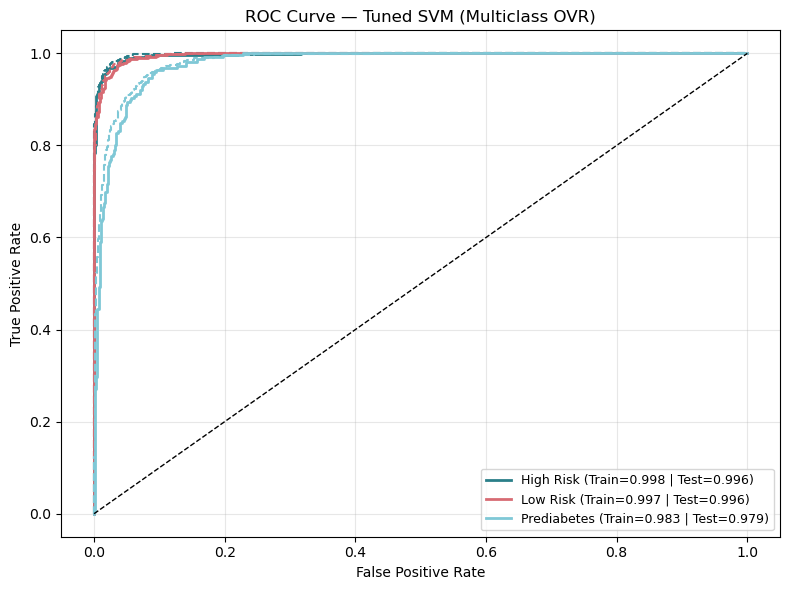

In [78]:
print("\n ROC Curve Analysis:")

# Shared color palette (same as all other ROC plots)
ROC_COLORS = ['#2A7F89', '#D76B73', '#7FC8D6']

plt.figure(figsize=(8, 6))

for i, (class_label, color) in enumerate(zip(classes_svm, ROC_COLORS)):
    fpr_train, tpr_train, _ = roc_curve(y_train_bin_svm[:, i], y_train_proba_svm_tuned[:, i])
    fpr_test,  tpr_test,  _ = roc_curve(y_test_bin_svm[:, i],  y_test_proba_svm_tuned[:, i])
    auc_train = auc(fpr_train, tpr_train)
    auc_test  = auc(fpr_test,  tpr_test)

    plt.plot(fpr_train, tpr_train, color=color, linestyle='--', linewidth=1.5)
    plt.plot(fpr_test,  tpr_test,  color=color, linestyle='-',  linewidth=2,
             label=f"{class_label} (Train={auc_train:.3f} | Test={auc_test:.3f})")

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.title('ROC Curve — Tuned SVM (Multiclass OVR)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## V. Model Comparison Summary

MODEL COMPARISON SUMMARY
               Model  Accuracy  Precision (macro)  Recall (macro)  F1 (macro)  AUC (OvR macro)
          LR (tuned)    0.9367             0.9162          0.9218      0.9188           0.9909
      LR (no tuning)    0.9375             0.9176          0.9217      0.9196           0.9907
         SVM (Tuned)    0.9283             0.9045          0.9246      0.9120           0.9905
             XGBoost    0.9333             0.9123          0.9166      0.9143           0.9888
            LightGBM    0.9300             0.9078          0.9131      0.9103           0.9885
   Gradient Boosting    0.9300             0.9080          0.9120      0.9099           0.9878
           SVM (RBF)    0.9242             0.9004          0.9259      0.9085           0.9878
           ANN (MLP)    0.9150             0.8893          0.8912      0.8903           0.9840
       Random Forest    0.9050             0.8765          0.8772      0.8768           0.9803
               RBFNN    0

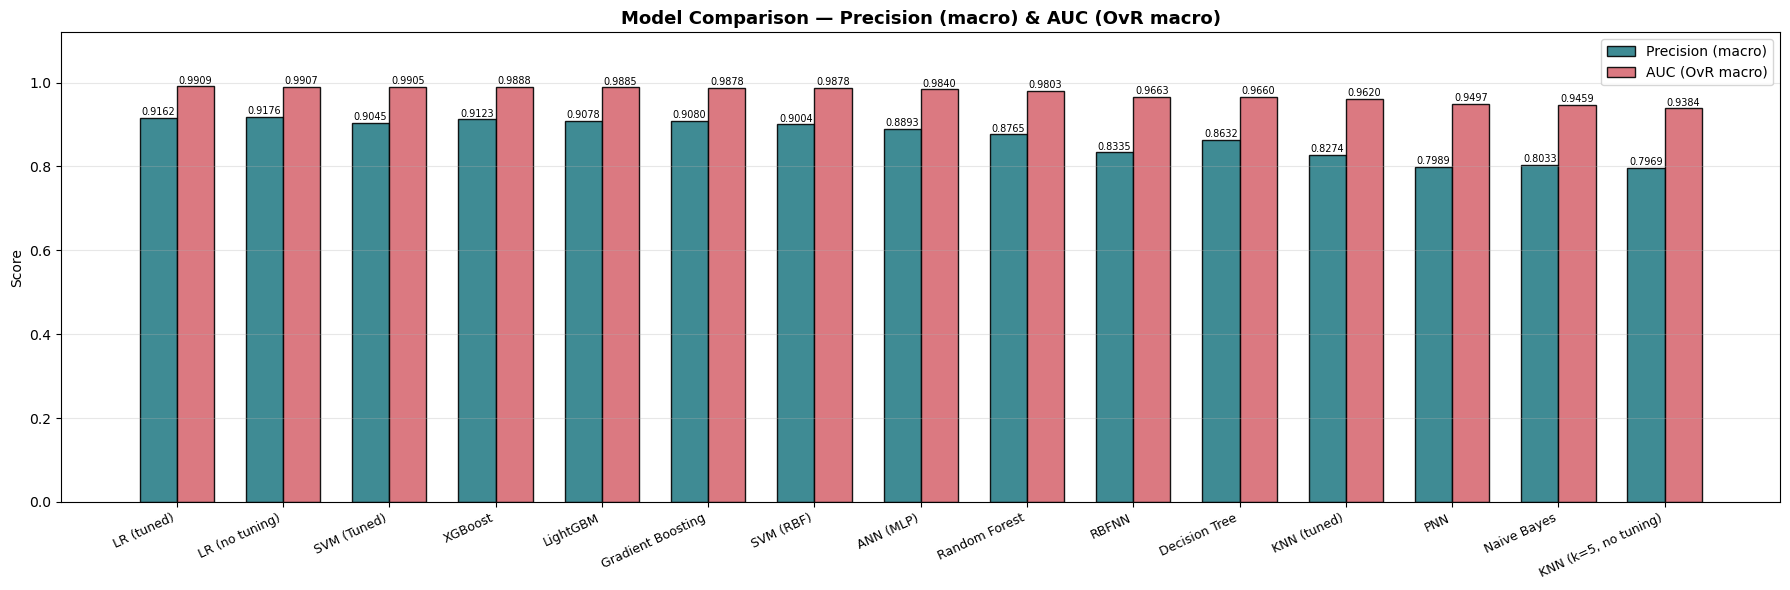

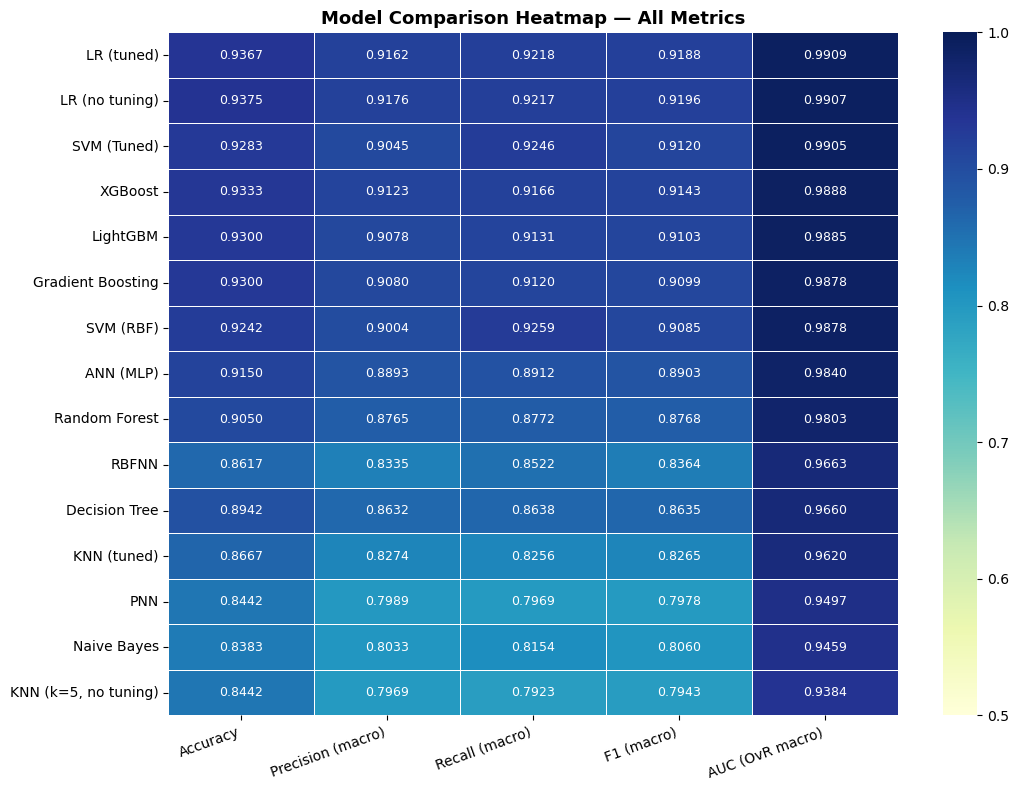

In [79]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import seaborn as sns

# Helper: collect all 5 metrics for any model
def get_all_metrics(model, X_te, y_te, model_name):
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_te, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_te, y_pred, average='macro', zero_division=0)
    auc  = roc_auc_score(y_te, y_proba, multi_class='ovr', average='macro')
    return {
        'Model'            : model_name,
        'Accuracy'         : round(acc,  4),
        'Precision (macro)': round(prec, 4),
        'Recall (macro)'   : round(rec,  4),
        'F1 (macro)'       : round(f1,   4),
        'AUC (OvR macro)'  : round(auc,  4),
    }

# Collect results for every model
summary_results = [
    get_all_metrics(logistic_reg, test_X_std, y_test,     'LR (no tuning)'),
    get_all_metrics(LR,           test_X_std, y_test,     'LR (tuned)'),
    get_all_metrics(gnb,          test_X_std, y_test,     'Naive Bayes'),
    get_all_metrics(knn_base,     test_X_std, y_test,     'KNN (k=5, no tuning)'),
    get_all_metrics(m_knn,        test_X_std, y_test,     'KNN (tuned)'),
    get_all_metrics(m_cart,       X_test,     y_test,     'Decision Tree'),
    get_all_metrics(m_rf,         X_test,     y_test,     'Random Forest'),
    get_all_metrics(m_gbc,        X_test,     y_test,     'Gradient Boosting'),
    get_all_metrics(m_lgb,        X_test,     y_test,     'LightGBM'),
    get_all_metrics(m_xgb,        X_test,     y_test_xgb, 'XGBoost'),
    get_all_metrics(ann,          X_test_np,  y_test_enc, 'ANN (MLP)'),
    get_all_metrics(rbfnn,        X_test_np,  y_test_enc, 'RBFNN'),
    get_all_metrics(pnn,          X_test_np,  y_test_enc, 'PNN'),
    get_all_metrics(svm,          test_X_std, y_test_enc, 'SVM (RBF)'),
    get_all_metrics(svm_tuned,    test_X_std, y_test_enc, 'SVM (Tuned)'),
]

summary_df = pd.DataFrame(summary_results).sort_values('AUC (OvR macro)', ascending=False).reset_index(drop=True)

print("=" * 90)
print("MODEL COMPARISON SUMMARY")
print("=" * 90)
print(summary_df.to_string(index=False))
print()

# ── Bar chart — Precision & AUC 
x     = np.arange(len(summary_df))
width = 0.35

fig, ax = plt.subplots(figsize=(18, 6))
bars1 = ax.bar(x - width/2, summary_df['Precision (macro)'],
               width, label='Precision (macro)', color='#2A7F89', edgecolor='black', alpha=0.9)
bars2 = ax.bar(x + width/2, summary_df['AUC (OvR macro)'],
               width, label='AUC (OvR macro)',   color='#D76B73', edgecolor='black', alpha=0.9)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(summary_df['Model'], rotation=25, ha='right', fontsize=9)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score")
ax.set_title("Model Comparison — Precision (macro) & AUC (OvR macro)", fontweight='bold', fontsize=13)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ── Heatmap — all 5 metrics 
metric_cols  = ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1 (macro)', 'AUC (OvR macro)']
heatmap_data = summary_df.set_index('Model')[metric_cols]

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='YlGnBu',
            linewidths=0.5, ax=ax, vmin=0.5, vmax=1.0,
            annot_kws={'size': 9})
ax.set_title("Model Comparison Heatmap — All Metrics", fontweight='bold', fontsize=13)
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=20, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()